# Lazada Uplift — Benchmark & Đánh giá cuối

Notebook thứ tư, khép lại phần Data Science. Nhận `best_params.json` từ `03_model_tuning.ipynb`
cùng 4 tập parquet, làm năm việc:

1. Xây bộ metric cho tập RCT (Qini, AUUC, ATE, uplift@k) và **kiểm chứng bằng bốn phép thử ngược trước khi dùng**
2. Huấn luyện lại 6 mô hình trên Train + Val gộp với tham số tốt nhất
3. Đấu 6 mô hình trên `rct_select` để chọn quán quân, kèm phân tích độ quan trọng đặc trưng và ablation
4. Mở `rct_holdout` **đúng một lần** để lấy con số báo cáo cuối, kèm khoảng tin cậy bootstrap
5. Xuất `model.pkl`, `metadata.json` và Feature Contract bàn giao cho DE

### Thứ tự các phần được sắp có chủ đích

Mọi quyết định có dính tới mô hình — chọn quán quân, chọn tập đặc trưng rút gọn — đều nằm **trước**
Phần 6. Khi tập `rct_holdout` được mở ra thì không còn gì để chọn nữa, chỉ còn đo và báo cáo.
Đây là điều kiện để con số cuối cùng giữ được giá trị khoa học: nếu nhìn kết quả holdout rồi quay lại
đổi mô hình thì nó thành tập validation thứ hai, không còn là ước lượng không chệch cho hiệu năng thật.

### Phân vai của các thước đo

| Nhóm | Metric | Dùng để | Tập nào |
|---|---|---|---|
| Tinh chỉnh | DR-MSE | Chọn siêu tham số | Val — đã làm xong ở notebook 03 |
| **Xếp hạng — chính** | **Hệ số Qini** | Chọn quán quân | `rct_select` |
| Nghiệp vụ | Uplift@10/20/30%, voucher tiết kiệm | Đưa lên slide | `rct_holdout` |
| Kiểm tra | ATE + khoảng tin cậy | Xác nhận không lệch hệ thống | `rct_holdout` |

Metric chính là **hệ số Qini** vì nó đo đúng thứ bài toán cần: khả năng *xếp hạng* ai đáng phát voucher.
Độ chính xác của giá trị CATE tuyệt đối thì thực tế không bao giờ kiểm chứng được, vì với mỗi khách hàng
ta chỉ quan sát được một trong hai kết quả tiềm năng.

---
# Phần 1 — Thiết lập

### Bước 1 — Import thư viện

In [1]:
!pip install -q econml optuna mlflow

In [2]:
import os
import json
import time
import pickle
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from econml.dml import LinearDML, NonParamDML, CausalForestDML

warnings.filterwarnings('ignore')

IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    print("📌 Đang chạy trên Kaggle Environment")
    DATA_DIR = '/kaggle/input/datasets/hatrungkienhatuki/lazada-uplift-data'
    ART_DIR = '/kaggle/working/artifacts'
    FIG_DIR = '/kaggle/working/reports/figures'
else:
    print("📌 Đang chạy trên máy Local")
    ROOT = '..' if os.path.basename(os.getcwd()) == 'notebooks' else '.'
    DATA_DIR = os.path.join(ROOT, 'dataset')
    ART_DIR = os.path.join(ROOT, 'artifacts')
    FIG_DIR = os.path.join(ROOT, 'reports', 'figures')

os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

# np.trapz đã đổi tên ở NumPy 2 — dùng bản nào có sẵn
TRAPZ = getattr(np, 'trapezoid', None) or np.trapz

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print(f"DATA_DIR: {DATA_DIR}")
print(f"ART_DIR : {ART_DIR}")

📌 Đang chạy trên máy Local
DATA_DIR: ../dataset
ART_DIR : ../artifacts


### Bước 2 — Chế độ chạy

Giống notebook 03: **chạy thử ở chế độ nhanh trước** để chắc chắn toàn bộ đường đi không lỗi,
rồi mới đổi sang chế độ đầy đủ. Ở chế độ nhanh, mô hình học trên mẫu con và bootstrap chỉ 100 lần —
kết quả không dùng để báo cáo được, nhưng chạy hết trong vài phút.

`N_FIT` là số dòng tối đa đưa vào huấn luyện. Ba mô hình dựa trên LightGBM ăn hết 926 nghìn dòng
không vấn đề gì. Ba mô hình EconML tốn hơn nhiều vì phải cross-fitting nhiều tầng, riêng
`CausalForestDML` còn dựng cả một rừng nhân quả với honest splitting nên được cấp mẫu nhỏ hơn hẳn.
Con số này được ghi vào bảng benchmark cuối, vì mô hình học trên ít dữ liệu hơn thì **không so sánh
ngang hàng được** — phải nói rõ thay vì giấu đi.

In [3]:
SMOKE_TEST = False           # <<< đổi thành False khi chạy thật

if SMOKE_TEST:
    N_BOOT = 100
    N_FIT = {'SLearner': 50_000, 'TLearner': 50_000, 'DRLearner': 50_000,
             'LinearDML': 50_000, 'NonParamDML': 50_000, 'CausalForestDML': 20_000}
else:
    N_BOOT = 1_000
    N_FIT = {'SLearner': None, 'TLearner': None, 'DRLearner': None,
             'LinearDML': 400_000, 'NonParamDML': 400_000, 'CausalForestDML': 200_000}

RUN_MODE = 'smoke_test' if SMOKE_TEST else 'full'

print('=' * 62)
print(f'  CHẾ ĐỘ: {RUN_MODE.upper()}')
print(f'  Bootstrap {N_BOOT:,} lần')
for k, v in N_FIT.items():
    print(f'    {k:<18} huấn luyện trên {"toàn bộ" if v is None else f"{v:,} dòng"}')
if SMOKE_TEST:
    print('  >>> KẾT QUẢ CHỈ ĐỂ KIỂM TRA CODE, KHÔNG DÙNG BÁO CÁO <<<')
print('=' * 62)

  CHẾ ĐỘ: FULL
  Bootstrap 1,000 lần
    SLearner           huấn luyện trên toàn bộ
    TLearner           huấn luyện trên toàn bộ
    DRLearner          huấn luyện trên toàn bộ
    LinearDML          huấn luyện trên 400,000 dòng
    NonParamDML        huấn luyện trên 400,000 dòng
    CausalForestDML    huấn luyện trên 200,000 dòng


### Bước 3 — Nạp tham số tốt nhất từ notebook 03

Kiểm tra ngay `run_mode`: nếu notebook 03 chạy ở chế độ smoke test thì tham số trong file là
tham số của một cuộc tìm kiếm hai trial, không dùng để báo cáo được.

In [4]:
with open(os.path.join(ART_DIR, 'best_params.json'), encoding='utf-8') as f:
    tuning = json.load(f)

BEST = tuning['best_params']
MODELS = ['SLearner', 'TLearner', 'DRLearner',
          'LinearDML', 'NonParamDML', 'CausalForestDML']

print(f"run_mode của notebook 03 : {tuning['run_mode']}")
if tuning['run_mode'] != 'full':
    print('  >>> CẢNH BÁO: tham số đến từ smoke test, không dùng cho báo cáo <<<')

fail = [m for m in MODELS if not BEST.get(m, {}).get('thanh_cong')]
print(f"Số mô hình có tham số dùng được : {len(MODELS) - len(fail)}/{len(MODELS)}")
if fail:
    print('  >>> Thiếu:', fail, '— quay lại notebook 03 <<<')

pd.DataFrame([{'Mô hình': m, 'DR-MSE': BEST[m]['dr_mse'], 'Số trial': BEST[m]['n_trials'],
               'Tham số': ', '.join(f'{k}={v}' for k, v in BEST[m]['params'].items())}
              for m in MODELS])

run_mode của notebook 03 : full
Số mô hình có tham số dùng được : 6/6


,Mô hình,DR-MSE,Số trial,Tham số
0,SLearner,0.323245,12,"n_estimators=300, learning_rate=0.011340440501..."
1,TLearner,0.323082,12,"n_estimators=400, learning_rate=0.022567926626..."
2,DRLearner,0.323849,12,"n_estimators=150, learning_rate=0.015256811898..."
3,LinearDML,0.323411,12,"nuisance_n_estimators=100, nuisance_max_depth=..."
4,NonParamDML,0.323399,12,"n_estimators=100, learning_rate=0.038227265746..."
5,CausalForestDML,0.323387,6,"nuisance_n_estimators=250, nuisance_max_depth=..."


Sáu con số DR-MSE nằm gọn trong khoảng rất hẹp, và mốc dự đoán hằng số ghi trong file
(`dr_mse_du_doan_hang_so`) cũng nằm ngay giữa khoảng đó. Notebook 03 đã giải thích nguyên nhân:
DR-MSE bị chi phối bởi phương sai rất lớn của chính DR-score, mà phần phương sai đó **giống nhau
với mọi mô hình**, nên nó gần như là một hằng số cộng thêm che mất phần chênh lệch thật.

Hệ quả cho notebook này: **không được dùng bảng trên để kết luận mô hình nào tốt hơn.** Nó đã hoàn
thành đúng nhiệm vụ của nó là chọn siêu tham số trong nội bộ từng mô hình, và dừng ở đó. Việc xếp
hạng giữa các mô hình thuộc về hệ số Qini đo trên tập RCT ở Phần 4, và bắt buộc phải kèm khoảng
tin cậy bootstrap.

### Bước 4 — Nạp dữ liệu

Nạp Train, Val và `rct_select`. **Không** chạm vào `rct_holdout` — tập đó chỉ được mở ở Phần 6.

In [5]:
info_path = os.path.join(ART_DIR, 'feature_info.json')
if not os.path.exists(info_path):
    info_path = os.path.join(DATA_DIR, 'feature_info.json')

with open(info_path, encoding='utf-8') as f:
    finfo = json.load(f)

FEATS = finfo['tat_ca_dac_trung']

train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
rct_sel = pd.read_parquet(os.path.join(DATA_DIR, 'rct_select.parquet'))

print(f'Train      : {len(train):>8,} dòng | treat {train.is_treat.mean()*100:5.2f}% '
      f'| mua {train.label.mean()*100:.2f}%')
print(f'Val        : {len(val):>8,} dòng | treat {val.is_treat.mean()*100:5.2f}% '
      f'| mua {val.label.mean()*100:.2f}%')
print(f'RCT-select : {len(rct_sel):>8,} dòng | treat {rct_sel.is_treat.mean()*100:5.2f}% '
      f'| mua {rct_sel.label.mean()*100:.2f}%')
print(f'\nĐặc trưng  : {len(FEATS)}')
print('RCT-holdout: chưa nạp — chỉ mở ở Phần 6')

Train      :  741,335 dòng | treat 22.17% | mua 1.99%
Val        :  185,334 dòng | treat 22.17% | mua 1.99%
RCT-select :   90,834 dòng | treat 52.12% | mua 3.52%

Đặc trưng  : 76
RCT-holdout: chưa nạp — chỉ mở ở Phần 6


---
# Phần 2 — Bộ metric và bốn phép kiểm chứng

Đây là phần quan trọng nhất của notebook, và là phần phải làm **trước** khi nhìn bất kỳ kết quả mô
hình nào. Lý do đơn giản: nếu công thức Qini sai thì mọi kết luận rút ra từ nó cũng sai theo, mà cái
sai đó rất khó phát hiện vì bảng kết quả vẫn in ra những con số trông hợp lý.

Cách phòng: viết metric xong thì thử ngược bằng những trường hợp đã biết trước đáp án.

### Bước 5 — Đường Qini và đường Cumulative Gain

Cả hai đường đều xây theo cùng một ý tưởng: sắp khách hàng giảm dần theo CATE dự đoán, rồi hỏi
*"nếu chỉ phát voucher cho k% đứng đầu thì được thêm bao nhiêu đơn hàng?"*.

Vướng mắc là trong nhóm k% đó có cả người thực sự nhận voucher lẫn người không, và số lượng hai
nhóm không bằng nhau. Hai đường xử lý chuyện đó theo hai cách khác nhau:

$$\text{Qini}(k) = Y^T_k - Y^C_k \cdot \frac{N^T_k}{N^C_k}
\qquad
\text{Gain}(k) = \left(\frac{Y^T_k}{N^T_k} - \frac{Y^C_k}{N^C_k}\right)(N^T_k + N^C_k)$$

Qini quy số đơn của nhóm control về cùng cỡ với nhóm treatment. Cumulative Gain lấy hiệu hai *tỉ lệ*
rồi nhân ngược lên cỡ nhóm. Khi hai nhóm cân bằng thì hai đường gần trùng nhau; khi lệch nhiều thì
Qini ổn định hơn ở đầu đường cong, nên nó được chọn làm metric chính.

Hai chi tiết kỹ thuật:

- **Phá thế hòa có seed.** Nhiều mô hình cho ra CATE trùng nhau ở hàng loạt dòng. Nếu để `argsort`
  tự xử thì thứ tự phụ thuộc thứ tự dòng trong file, và một mô hình dự đoán hằng số có thể ăn may
  điểm cao. Xáo ngẫu nhiên trong nhóm hòa, có seed để chạy lại ra đúng kết quả cũ.
- **Chia cho cỡ mẫu.** Đường cong tính theo số đơn tuyệt đối sẽ phụ thuộc cỡ tập. Chia cho `n` để
  so sánh được giữa `rct_select` và `rct_holdout`.

In [6]:
def _sap_xep(y, w, score, seed=SEED):
    '''Sắp giảm dần theo score, phá thế hòa ngẫu nhiên có seed.'''
    n = len(y)
    rng = np.random.RandomState(seed)
    order = np.lexsort((rng.rand(n), -np.asarray(score, dtype=float)))
    y_, w_ = np.asarray(y)[order], np.asarray(w)[order]
    return (np.cumsum(w_), np.cumsum(1 - w_),
            np.cumsum(y_ * w_), np.cumsum(y_ * (1 - w_)))


def qini_curve(y, w, score, seed=SEED):
    '''Trả về (x = tỉ lệ dân số được nhắm, y = số đơn tăng thêm trên mỗi người).'''
    nt, nc, yt, yc = _sap_xep(y, w, score, seed)
    n = len(y)
    ty_le = np.divide(nt, nc, out=np.zeros(n), where=nc > 0)
    return np.arange(1, n + 1) / n, (yt - yc * ty_le) / n


def gain_curve(y, w, score, seed=SEED):
    n = len(y)
    nt, nc, yt, yc = _sap_xep(y, w, score, seed)
    r_t = np.divide(yt, nt, out=np.zeros(n), where=nt > 0)
    r_c = np.divide(yc, nc, out=np.zeros(n), where=nc > 0)
    return np.arange(1, n + 1) / n, (r_t - r_c) * (nt + nc) / n


print('Đã định nghĩa qini_curve và gain_curve')

Đã định nghĩa qini_curve và gain_curve


### Bước 6 — Hệ số Qini và AUUC

Đường cong là một dãy số, cần thu về một con số duy nhất để xếp hạng.

Mốc so sánh là **đường chéo ngẫu nhiên**: nếu phát voucher cho một nhóm ngẫu nhiên k% thì thu được
đúng k% của tổng hiệu ứng, tức một đường thẳng nối gốc tọa độ tới điểm cuối. Diện tích giữa đường
cong của mô hình và đường chéo đó chính là phần giá trị mà việc xếp hạng mang lại.

Diện tích thô có đơn vị "đơn hàng trên mỗi người", cỡ khoảng $10^{-4}$ trên bộ dữ liệu này —
đúng nhưng khó đọc. Nên chia thêm cho diện tích của một **xếp hạng biết trước đáp án**:

```
score_oracle = +1 nếu (nhận voucher và có mua)
               -1 nếu (không nhận voucher mà vẫn mua)
                0 còn lại
```

Xếp hạng này đẩy toàn bộ người "mua khi có voucher" lên đầu và người "mua kể cả khi không có voucher"
xuống cuối, tức là đường Qini dốc nhất có thể đạt được trên chính tập dữ liệu đó. Nó nhìn vào nhãn
thật nên không phải mô hình — chỉ là **trần trên** để quy về thang 0–1.

Với cách chuẩn hóa này: xếp hạng ngẫu nhiên cho khoảng 0, xếp hạng biết trước cho đúng 1,0. Mô hình
thật nằm đâu đó ở giữa, và con số đọc ra là *"đạt được bao nhiêu phần trăm của mức tốt nhất có thể"*.

In [7]:
def oracle_score(y, w):
    '''Xếp hạng biết trước đáp án — trần trên để chuẩn hóa, không phải mô hình.'''
    return np.where(np.asarray(w) == 1, y, -np.asarray(y)).astype(float)


def _dien_tich_tren_duong_cheo(x, g):
    '''Diện tích giữa đường cong và đường chéo ngẫu nhiên.'''
    return float(TRAPZ(g, x) - 0.5 * g[-1])


def qini_tho(y, w, score, seed=SEED):
    return _dien_tich_tren_duong_cheo(*qini_curve(y, w, score, seed))


def qini_score(y, w, score, seed=SEED):
    '''Hệ số Qini chuẩn hóa — metric chính. Ngẫu nhiên ≈ 0, biết trước = 1.'''
    tran = qini_tho(y, w, oracle_score(y, w), seed)
    return qini_tho(y, w, score, seed) / tran if tran > 0 else np.nan


def auuc_score(y, w, score, seed=SEED):
    '''Tương tự nhưng trên đường Cumulative Gain — dùng để đối chiếu.'''
    x, g = gain_curve(y, w, score, seed)
    xo, go = gain_curve(y, w, oracle_score(y, w), seed)
    tran = _dien_tich_tren_duong_cheo(xo, go)
    return _dien_tich_tren_duong_cheo(x, g) / tran if tran > 0 else np.nan


print('Đã định nghĩa qini_score và auuc_score')

Đã định nghĩa qini_score và auuc_score


### Bước 7 — ATE kèm khoảng tin cậy

Trên tập RCT, việc phát voucher là ngẫu nhiên nên hiệu hai tỉ lệ chuyển đổi đã là ước lượng không
chệch cho ATE, không cần hiệu chỉnh gì thêm. Sai số chuẩn theo công thức hiệu hai tỉ lệ:

$$\widehat{SE} = \sqrt{\frac{p_1(1-p_1)}{n_1} + \frac{p_0(1-p_0)}{n_0}}$$

In [8]:
def ate_with_ci(y, w, alpha=0.05):
    '''ATE, sai số chuẩn và khoảng tin cậy trên tập RCT.'''
    y = np.asarray(y, dtype=float)
    w = np.asarray(w)
    y1, y0 = y[w == 1], y[w == 0]
    p1, p0 = y1.mean(), y0.mean()
    se = np.sqrt(p1 * (1 - p1) / len(y1) + p0 * (1 - p0) / len(y0))
    z = stats.norm.ppf(1 - alpha / 2)
    ate = p1 - p0
    return {'ate': float(ate), 'se': float(se),
            'ci_thap': float(ate - z * se), 'ci_cao': float(ate + z * se),
            'n_treat': int(len(y1)), 'n_control': int(len(y0))}


def uplift_at_k(y, w, score, k=0.2, seed=SEED):
    '''Uplift thực đo trong nhóm k% có CATE dự đoán cao nhất.'''
    n = len(y)
    rng = np.random.RandomState(seed)
    order = np.lexsort((rng.rand(n), -np.asarray(score, dtype=float)))
    top = order[:max(1, int(round(k * n)))]
    yt, wt = np.asarray(y)[top], np.asarray(w)[top]
    if wt.sum() == 0 or (1 - wt).sum() == 0:
        return np.nan
    return float(yt[wt == 1].mean() - yt[wt == 0].mean())


print('Đã định nghĩa ate_with_ci và uplift_at_k')

Đã định nghĩa ate_with_ci và uplift_at_k


### Bước 8 — Khoảng tin cậy bootstrap

EDA cho thấy tín hiệu trong bộ dữ liệu này rất yếu. ATE trên toàn tập RCT chỉ khoảng 0,37 điểm phần
trăm với khoảng tin cậy xấp xỉ ±0,17 pp — tức chỉ hơn hai lần sai số chuẩn. Mỗi tập RCT sau khi cắt
đôi chỉ còn khoảng 91 nghìn dòng nên sai số còn nở thêm.

Trong hoàn cảnh đó, **chênh lệch Qini giữa các mô hình rất dễ nằm trọn trong vùng nhiễu**. Một mô
hình đạt 0,041 và một mô hình đạt 0,039 thì gần như chắc chắn là ngẫu nhiên chứ không phải mô hình
thứ nhất giỏi hơn.

Cách duy nhất để biết được điều đó là bootstrap: lấy mẫu lại có hoàn lại `N_BOOT` lần, tính Qini mỗi
lần, rồi lấy phân vị 2,5% và 97,5%. Báo cáo dạng `Qini = 0,041 [0,028 – 0,055]`.

Nếu khoảng tin cậy của các mô hình chồng lấn nhau thì kết luận trung thực là *"các phương pháp không
khác biệt có ý nghĩa thống kê trên bộ dữ liệu này"*. Đó là một kết luận nghiên cứu hợp lệ, và tốt hơn
nhiều so với việc tuyên bố quán quân dựa trên chênh lệch ở chữ số thứ ba.

Lưu ý về cách chuẩn hóa: trần trên được **tính lại trong từng lần lấy mẫu**, vì mẫu bootstrap có
thành phần nhãn khác mẫu gốc. Dùng chung một trần cố định sẽ làm khoảng tin cậy hẹp đi một cách giả tạo.

In [9]:
def bootstrap_ci(ham, y, w, score, n_boot=None, seed=SEED, alpha=0.05):
    '''Khoảng tin cậy phân vị. Trả về (giá trị gốc, ci_thấp, ci_cao, dãy bootstrap).'''
    n_boot = N_BOOT if n_boot is None else n_boot
    y, w, score = np.asarray(y), np.asarray(w), np.asarray(score, dtype=float)
    n = len(y)
    goc = ham(y, w, score)

    rng = np.random.RandomState(seed)
    vals = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        try:
            vals[b] = ham(y[idx], w[idx], score[idx])
        except Exception:
            vals[b] = np.nan

    vals = vals[np.isfinite(vals)]
    lo, hi = np.percentile(vals, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(goc), float(lo), float(hi), vals


def fmt_ci(goc, lo, hi, nhan=3):
    return f'{goc:.{nhan}f} [{lo:.{nhan}f} – {hi:.{nhan}f}]'


print(f'Bootstrap {N_BOOT:,} lần mỗi phép đo')

Bootstrap 1,000 lần mỗi phép đo


---
### Kiểm chứng metric — bốn phép thử ngược

Bốn trường hợp đã biết trước đáp án. Nếu một phép thử sai thì công thức sai, phải sửa trước khi đi tiếp.
Toàn bộ chạy trên `rct_select`, không đụng tới holdout.

### Bước 9 — Phép thử 1: xếp hạng ngẫu nhiên phải cho Qini ≈ 0

Cho điểm hoàn toàn ngẫu nhiên thì việc "chọn top k%" không khác gì chọn bừa, nên đường cong phải nằm
sát đường chéo và hệ số Qini phải xấp xỉ 0. Quan trọng hơn con số điểm: khoảng tin cậy bootstrap
**phải chứa số 0**. Nếu không thì công thức có thiên vị hệ thống.

In [10]:
y_sel = rct_sel['label'].values
w_sel = rct_sel['is_treat'].values

score_ngau_nhien = np.random.RandomState(SEED).randn(len(rct_sel))

q_rnd, lo_rnd, hi_rnd, _ = bootstrap_ci(qini_score, y_sel, w_sel, score_ngau_nhien)
chua_khong = lo_rnd <= 0 <= hi_rnd

print(f'Qini của xếp hạng ngẫu nhiên : {fmt_ci(q_rnd, lo_rnd, hi_rnd, 4)}')
print(f'Khoảng tin cậy có chứa 0     : {"ĐẠT" if chua_khong else "KHÔNG ĐẠT"}')

Qini của xếp hạng ngẫu nhiên : -0.0051 [-0.0264 – 0.0150]
Khoảng tin cậy có chứa 0     : ĐẠT


### Bước 10 — Phép thử 2: `ate_with_ci` phải khớp với phép tính tay

Không dùng thư viện, không dùng hàm vừa viết — tính thẳng hiệu hai tỉ lệ bằng `mean()` rồi so sánh.
Hai con số phải khớp tới từng chữ số của độ chính xác máy.

In [11]:
kq_ate = ate_with_ci(y_sel, w_sel)

# tính tay hoàn toàn độc lập
p1_tay = y_sel[w_sel == 1].mean()
p0_tay = y_sel[w_sel == 0].mean()
ate_tay = p1_tay - p0_tay

sai_lech = abs(kq_ate['ate'] - ate_tay)
khop = sai_lech < 1e-12

print(f'Tỉ lệ mua nhóm có voucher    : {p1_tay*100:.4f}%')
print(f'Tỉ lệ mua nhóm không voucher : {p0_tay*100:.4f}%')
print(f'ATE tính tay                 : {ate_tay*100:.4f} pp')
print(f'ATE từ hàm                   : {kq_ate["ate"]*100:.4f} pp')
print(f'Sai lệch                     : {sai_lech:.2e}  ->  {"ĐẠT" if khop else "KHÔNG ĐẠT"}')
print(f'\nKhoảng tin cậy 95%           : [{kq_ate["ci_thap"]*100:.4f} pp, {kq_ate["ci_cao"]*100:.4f} pp]')
print(f'Có khác 0 có ý nghĩa         : {"có" if kq_ate["ci_thap"] > 0 else "KHÔNG"}')

Tỉ lệ mua nhóm có voucher    : 3.6988%
Tỉ lệ mua nhóm không voucher : 3.3269%
ATE tính tay                 : 0.3719 pp
ATE từ hàm                   : 0.3719 pp
Sai lệch                     : 0.00e+00  ->  ĐẠT

Khoảng tin cậy 95%           : [0.1325 pp, 0.6113 pp]
Có khác 0 có ý nghĩa         : có


### Bước 11 — Phép thử 3: xếp hạng biết trước phải cao hơn hẳn ngẫu nhiên

Nói thẳng giới hạn của phép thử này: vì trần chuẩn hóa **chính là** diện tích của xếp hạng biết trước,
nên `qini_score` của nó bằng 1,0 theo định nghĩa. Con số 1,0 chỉ xác nhận phần chuẩn hóa cài đúng,
không phải một phép thử độc lập.

Phần có giá trị là so sánh trên **diện tích thô**, thứ không dính tới chuẩn hóa: diện tích của xếp
hạng biết trước phải lớn hơn hẳn của xếp hạng ngẫu nhiên, và phải dương.

In [12]:
s_oracle = oracle_score(y_sel, w_sel)

dt_oracle = qini_tho(y_sel, w_sel, s_oracle)
dt_ngau_nhien = qini_tho(y_sel, w_sel, score_ngau_nhien)

cao_hon = dt_oracle > 0 and abs(dt_oracle) > 10 * abs(dt_ngau_nhien)

print(f'Diện tích thô — biết trước : {dt_oracle:.3e}')
print(f'Diện tích thô — ngẫu nhiên : {dt_ngau_nhien:.3e}')
print(f'Tỉ số                      : {dt_oracle/abs(dt_ngau_nhien):.1f} lần')
print(f'Kết quả                    : {"ĐẠT" if cao_hon else "KHÔNG ĐẠT"}')
print(f'\nQini chuẩn hóa của xếp hạng biết trước: {qini_score(y_sel, w_sel, s_oracle):.4f}'
      '  (bằng 1,0 theo định nghĩa)')

Diện tích thô — biết trước : 1.798e-02
Diện tích thô — ngẫu nhiên : -9.198e-05
Tỉ số                      : 195.5 lần
Kết quả                    : ĐẠT

Qini chuẩn hóa của xếp hạng biết trước: 1.0000  (bằng 1,0 theo định nghĩa)


### Bước 12 — Phép thử 4: pha nhiễu dần vào xếp hạng, Qini phải giảm đơn điệu

Đây mới là phép thử thật sự có sức nặng, vì nó không dựa vào bất kỳ trường hợp biên nào.

Ý tưởng: lấy xếp hạng biết trước rồi pha nhiễu vào với biên độ tăng dần. Chất lượng xếp hạng suy
giảm dần từ hoàn hảo về ngẫu nhiên, nên hệ số Qini **phải giảm đơn điệu** theo. Nếu nó nhảy lung tung
thì metric không phản ứng đúng với chất lượng xếp hạng, và mọi so sánh dựa trên nó đều vô nghĩa.

In [13]:
muc_nhieu = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
rng = np.random.RandomState(SEED)
nhieu = rng.randn(len(y_sel))

thang_do = s_oracle.std()
kq_nhieu = []
for m in muc_nhieu:
    s = s_oracle + m * thang_do * nhieu
    kq_nhieu.append({'Biên độ nhiễu': m, 'Qini': qini_score(y_sel, w_sel, s)})

bang_nhieu = pd.DataFrame(kq_nhieu)
giam_don_dieu = bool(np.all(np.diff(bang_nhieu['Qini'].values) <= 1e-9))

print(bang_nhieu.round(4).to_string(index=False))
print(f'\nGiảm đơn điệu: {"ĐẠT" if giam_don_dieu else "KHÔNG ĐẠT"}')

 Biên độ nhiễu   Qini
          0.00 1.0000
          0.25 1.0000
          0.50 1.0000
          1.00 0.9999
          2.00 0.9449
          4.00 0.6591
          8.00 0.3622

Giảm đơn điệu: ĐẠT


### Bước 13 — Trực quan hóa bốn phép kiểm chứng

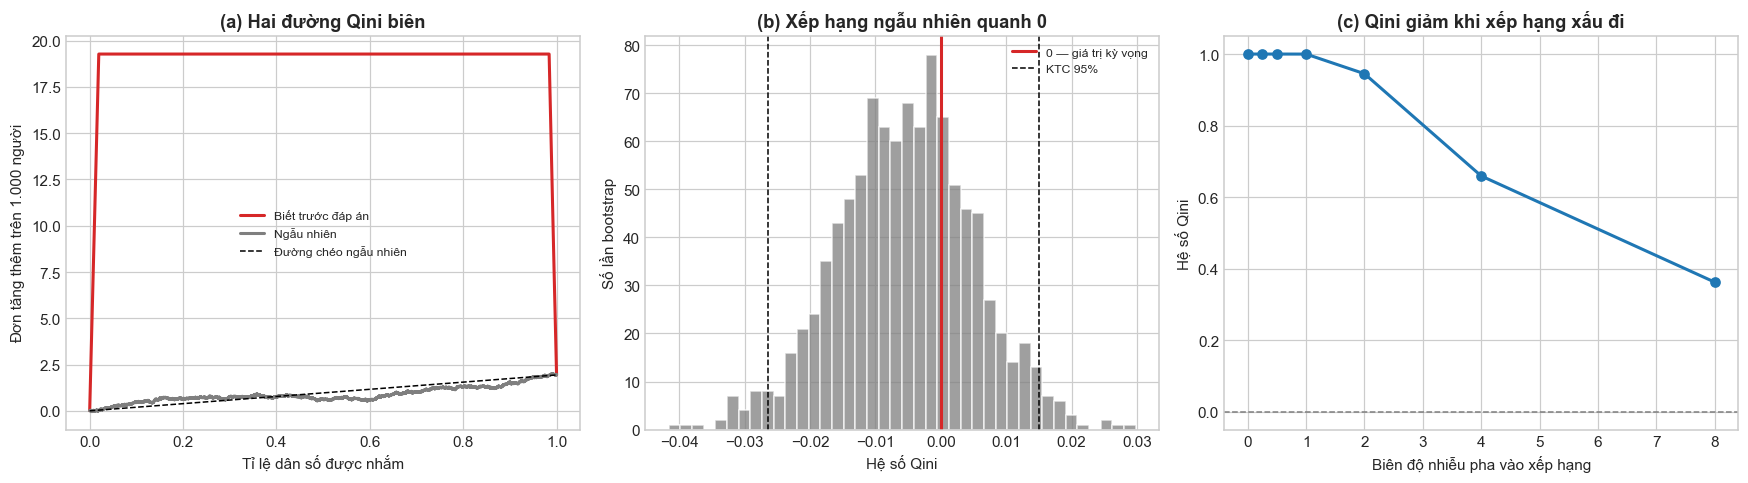

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) ba đường Qini
for s, nhan, mau in [(s_oracle, 'Biết trước đáp án', '#d62728'),
                     (score_ngau_nhien, 'Ngẫu nhiên', '#7f7f7f')]:
    x, g = qini_curve(y_sel, w_sel, s)
    axes[0].plot(x, g * 1000, label=nhan, color=mau, lw=2)
x, g = qini_curve(y_sel, w_sel, s_oracle)
axes[0].plot([0, 1], [0, g[-1] * 1000], '--', color='black', lw=1, label='Đường chéo ngẫu nhiên')
axes[0].set_xlabel('Tỉ lệ dân số được nhắm')
axes[0].set_ylabel('Đơn tăng thêm trên 1.000 người')
axes[0].set_title('(a) Hai đường Qini biên')
axes[0].legend(fontsize=8)

# (b) phân phối bootstrap của xếp hạng ngẫu nhiên
_, _, _, vals_rnd = bootstrap_ci(qini_score, y_sel, w_sel, score_ngau_nhien)
axes[1].hist(vals_rnd, bins=40, color='#7f7f7f', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='#d62728', lw=2, label='0 — giá trị kỳ vọng')
axes[1].axvline(lo_rnd, color='black', ls='--', lw=1)
axes[1].axvline(hi_rnd, color='black', ls='--', lw=1, label='KTC 95%')
axes[1].set_xlabel('Hệ số Qini')
axes[1].set_ylabel('Số lần bootstrap')
axes[1].set_title('(b) Xếp hạng ngẫu nhiên quanh 0')
axes[1].legend(fontsize=8)

# (c) suy giảm theo nhiễu
axes[2].plot(bang_nhieu['Biên độ nhiễu'], bang_nhieu['Qini'], 'o-', color='#1f77b4', lw=2)
axes[2].axhline(0, color='#7f7f7f', ls='--', lw=1)
axes[2].set_xlabel('Biên độ nhiễu pha vào xếp hạng')
axes[2].set_ylabel('Hệ số Qini')
axes[2].set_title('(c) Qini giảm khi xếp hạng xấu đi')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '14_kiem_chung_metric.png'), bbox_inches='tight')
plt.show()

### Bước 14 — Chốt cổng

Bốn phép thử phải đạt hết thì mới được đi tiếp. Dùng `assert` chứ không chỉ in ra màn hình, để nếu
sau này ai chạy lại notebook mà metric hỏng thì notebook dừng ngay tại đây thay vì tiếp tục sinh ra
một bảng benchmark sai.

In [15]:
kiem_chung = pd.DataFrame([
    {'Phép thử': '1. Xếp hạng ngẫu nhiên → Qini ≈ 0',
     'Kết quả': fmt_ci(q_rnd, lo_rnd, hi_rnd, 4), 'Đạt': chua_khong},
    {'Phép thử': '2. ATE khớp phép tính tay',
     'Kết quả': f'sai lệch {sai_lech:.1e}', 'Đạt': khop},
    {'Phép thử': '3. Biết trước ≫ ngẫu nhiên',
     'Kết quả': f'{dt_oracle/abs(dt_ngau_nhien):.0f} lần', 'Đạt': cao_hon},
    {'Phép thử': '4. Qini giảm đơn điệu theo nhiễu',
     'Kết quả': f'{bang_nhieu.Qini.iloc[0]:.3f} → {bang_nhieu.Qini.iloc[-1]:.3f}',
     'Đạt': giam_don_dieu},
])

display(kiem_chung)

assert kiem_chung['Đạt'].all(), 'Có phép kiểm chứng không đạt — sửa công thức metric trước khi đi tiếp'
print('\n✅ Bộ metric đã qua cả bốn phép kiểm chứng, dùng được cho các phần sau.')

,Phép thử,Kết quả,Đạt
0,1. Xếp hạng ngẫu nhiên → Qini ≈ 0,-0.0051 [-0.0264 – 0.0150],True
1,2. ATE khớp phép tính tay,sai lệch 0.0e+00,True
2,3. Biết trước ≫ ngẫu nhiên,196 lần,True
3,4. Qini giảm đơn điệu theo nhiễu,1.000 → 0.362,True



✅ Bộ metric đã qua cả bốn phép kiểm chứng, dùng được cho các phần sau.


---
# Phần 3 — Huấn luyện lại 6 mô hình

Notebook 03 tìm siêu tham số trên mẫu con để tiết kiệm thời gian. Giờ dùng lại đúng bộ tham số đó
nhưng huấn luyện trên **Train + Val gộp lại**: đã tinh chỉnh xong thì không còn lý do giữ Val riêng,
và thêm 185 nghìn dòng là thêm dữ liệu học miễn phí.

### Bước 15 — Định nghĩa lại 6 mô hình

Chép nguyên từ notebook 03, không sửa gì. Các notebook cố tình không import lẫn nhau — mỗi cái phải
chạy độc lập từ trên xuống — nên phải lặp lại phần định nghĩa. Đổi lại, nếu sau này ai chỉ mở
notebook 04 thì vẫn đọc hiểu được toàn bộ mô hình mà không phải mở file khác.

Một thay đổi nhỏ duy nhất: DR-Learner được đặt `importance_type='gain'`. Mặc định của LightGBM là
đếm **số lần** một đặc trưng được dùng để chia nhánh, cách đó thiên vị nặng cho đặc trưng liên tục
nhiều giá trị vì chúng có nhiều điểm cắt để thử. Gần một nửa số cột ở đây là nhị phân, dùng mặc định
sẽ đánh giá thấp chúng một cách oan uổng. `gain` đo mức giảm hàm mất mát thực tế mà mỗi lần chia
mang lại, công bằng giữa hai loại.

In [16]:
def compute_dr_scores(X, W, Y, n_folds=5, seed=SEED, clip=(0.01, 0.99)):
    '''Pseudo-outcome doubly robust, ước lượng bằng cross-fitting.'''
    n = len(X)
    e_hat = np.zeros(n)
    mu0_hat = np.zeros(n)
    mu1_hat = np.zeros(n)

    strata = W * 2 + Y
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

    nuisance_params = dict(n_estimators=200, learning_rate=0.05, max_depth=5,
                           min_child_samples=50, random_state=seed, verbose=-1)

    for tr, te in skf.split(X, strata):
        m_e = lgb.LGBMClassifier(**nuisance_params).fit(X[tr], W[tr])
        e_hat[te] = np.clip(m_e.predict_proba(X[te])[:, 1], *clip)

        m0 = lgb.LGBMClassifier(**nuisance_params).fit(X[tr][W[tr] == 0], Y[tr][W[tr] == 0])
        m1 = lgb.LGBMClassifier(**nuisance_params).fit(X[tr][W[tr] == 1], Y[tr][W[tr] == 1])
        mu0_hat[te] = m0.predict_proba(X[te])[:, 1]
        mu1_hat[te] = m1.predict_proba(X[te])[:, 1]

    dr = ((mu1_hat - mu0_hat)
          + W * (Y - mu1_hat) / e_hat
          - (1 - W) * (Y - mu0_hat) / (1 - e_hat))

    return dr, e_hat, mu0_hat, mu1_hat


class SLearner:
    '''Một mô hình duy nhất trên [X, W]. CATE = f(X,1) - f(X,0).'''
    def __init__(self, **params):
        self.params = dict(params, random_state=SEED, verbose=-1)

    def fit(self, X, W, Y):
        self.model = lgb.LGBMClassifier(**self.params).fit(np.column_stack([X, W]), Y)
        return self

    def predict_cate(self, X):
        n = len(X)
        p1 = self.model.predict_proba(np.column_stack([X, np.ones(n)]))[:, 1]
        p0 = self.model.predict_proba(np.column_stack([X, np.zeros(n)]))[:, 1]
        return p1 - p0


class TLearner:
    '''Hai mô hình riêng cho nhóm treatment và control. CATE = f1(X) - f0(X).'''
    def __init__(self, **params):
        self.params = dict(params, random_state=SEED, verbose=-1)

    def fit(self, X, W, Y):
        self.m1 = lgb.LGBMClassifier(**self.params).fit(X[W == 1], Y[W == 1])
        self.m0 = lgb.LGBMClassifier(**self.params).fit(X[W == 0], Y[W == 0])
        return self

    def predict_cate(self, X):
        return self.m1.predict_proba(X)[:, 1] - self.m0.predict_proba(X)[:, 1]


class DRLearner:
    '''Kennedy 2020 — hồi quy pseudo-outcome doubly robust.'''
    def __init__(self, n_folds=5, **params):
        self.n_folds = n_folds
        self.params = dict(params, random_state=SEED, verbose=-1, importance_type='gain')

    def fit(self, X, W, Y):
        dr_train, *_ = compute_dr_scores(X, W, Y, n_folds=self.n_folds)
        self.model = lgb.LGBMRegressor(**self.params).fit(X, dr_train)
        return self

    def predict_cate(self, X):
        return self.model.predict(X)


class EconMLWrapper:
    '''Bọc estimator của EconML về cùng giao diện fit/predict_cate.'''
    def __init__(self, estimator):
        self.est = estimator

    def fit(self, X, W, Y):
        self.est.fit(Y, W, X=X)
        return self

    def predict_cate(self, X):
        return np.asarray(self.est.effect(X)).ravel()


print('Đã định nghĩa 6 lớp mô hình')

Đã định nghĩa 6 lớp mô hình


### Bước 16 — Hàm dựng mô hình từ tên và tham số

In [17]:
def make_nuisance(p):
    common = dict(n_estimators=p['nuisance_n_estimators'], learning_rate=0.05,
                  max_depth=p['nuisance_max_depth'], random_state=SEED, verbose=-1)
    return lgb.LGBMRegressor(**common), lgb.LGBMClassifier(**common)


def build_model(name, p):
    if name == 'SLearner':
        return SLearner(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                        max_depth=p['max_depth'], min_child_samples=p['min_child_samples'])
    if name == 'TLearner':
        return TLearner(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                        max_depth=p['max_depth'], min_child_samples=p['min_child_samples'])
    if name == 'DRLearner':
        return DRLearner(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                         max_depth=p['max_depth'], min_child_samples=p['min_child_samples'])

    model_y, model_t = make_nuisance(p)
    if name == 'LinearDML':
        return EconMLWrapper(LinearDML(
            model_y=model_y, model_t=model_t, discrete_treatment=True,
            cv=p['cv'], random_state=SEED))
    if name == 'NonParamDML':
        return EconMLWrapper(NonParamDML(
            model_y=model_y, model_t=model_t,
            model_final=lgb.LGBMRegressor(
                n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                max_depth=p['max_depth'], min_child_samples=p['min_child_samples'],
                random_state=SEED, verbose=-1),
            discrete_treatment=True, cv=p['cv'], random_state=SEED))
    if name == 'CausalForestDML':
        return EconMLWrapper(CausalForestDML(
            model_y=model_y, model_t=model_t, discrete_treatment=True,
            n_estimators=p['cf_n_estimators'], min_samples_leaf=p['cf_min_samples_leaf'],
            max_depth=p['cf_max_depth'], cv=p['cv'], random_state=SEED))

    raise ValueError(f'Không biết mô hình: {name}')


print('Đã định nghĩa build_model')

Đã định nghĩa build_model


### Bước 17 — Gộp Train + Val

Dùng `float32` thay vì `float64`: 926 nghìn dòng × 76 cột ở `float64` chiếm khoảng 560 MB, còn
`float32` chỉ khoảng 280 MB. LightGBM lượng tử hóa đặc trưng thành histogram 256 bin trước khi học
nên độ chính xác dôi ra của `float64` không được dùng tới.

In [18]:
full = pd.concat([train, val], ignore_index=True)

X_full = full[FEATS].values.astype(np.float32)
W_full = full['is_treat'].values
Y_full = full['label'].values

X_sel = rct_sel[FEATS].values.astype(np.float32)

print(f'Tập huấn luyện gộp : {len(full):,} dòng × {len(FEATS)} đặc trưng')
print(f'  treat {W_full.mean()*100:.2f}% | mua {Y_full.mean()*100:.2f}%')
print(f'  bộ nhớ X: {X_full.nbytes/1e6:.0f} MB')
print(f'Tập RCT-select     : {len(rct_sel):,} dòng')

Tập huấn luyện gộp : 926,669 dòng × 76 đặc trưng
  treat 22.17% | mua 1.99%
  bộ nhớ X: 282 MB
Tập RCT-select     : 90,834 dòng


### Bước 18 — Vòng huấn luyện

Chạy lâu — ở chế độ đầy đủ khoảng 40 đến 60 phút tùy máy. Mô hình nào lỗi thì ghi lại và bỏ qua chứ
không làm hỏng cả vòng, giống cách notebook 03 xử lý trial lỗi.

In [19]:
def lay_mau(n_max, seed=SEED):
    '''Lấy mẫu phân tầng theo cặp (W, Y) để giữ nguyên tỉ lệ 4 tổ hợp.'''
    if n_max is None or n_max >= len(full):
        return np.arange(len(full))
    strata = W_full * 2 + Y_full
    rng = np.random.RandomState(seed)
    idx = []
    for s in np.unique(strata):
        pos = np.where(strata == s)[0]
        k = max(1, int(round(n_max * len(pos) / len(full))))
        idx.append(rng.choice(pos, size=min(k, len(pos)), replace=False))
    return np.sort(np.concatenate(idx))


models, cate_sel, thoi_gian, n_dong_fit, loi = {}, {}, {}, {}, {}

for name in MODELS:
    if not BEST.get(name, {}).get('thanh_cong'):
        loi[name] = 'không có tham số dùng được từ notebook 03'
        print(f'{name:<18} BỎ QUA — {loi[name]}')
        continue

    idx = lay_mau(N_FIT[name])
    t0 = time.time()
    try:
        m = build_model(name, BEST[name]['params']).fit(X_full[idx], W_full[idx], Y_full[idx])
        cate = m.predict_cate(X_sel)
        if not np.all(np.isfinite(cate)):
            raise ValueError('CATE chứa giá trị không hữu hạn')
        models[name], cate_sel[name] = m, cate
        thoi_gian[name] = time.time() - t0
        n_dong_fit[name] = len(idx)
        print(f'{name:<18} {len(idx):>8,} dòng | {thoi_gian[name]:>6.1f}s | '
              f'CATE trung bình {cate.mean():+.5f} | độ lệch chuẩn {cate.std():.5f}')
    except Exception as exc:
        loi[name] = f'{type(exc).__name__}: {exc}'
        print(f'{name:<18} LỖI — {loi[name]}')

OK_MODELS = [m for m in MODELS if m in models]
print(f'\n{len(OK_MODELS)}/{len(MODELS)} mô hình huấn luyện thành công')

SLearner            926,669 dòng |    6.9s | CATE trung bình +0.01546 | độ lệch chuẩn 0.02015
TLearner            926,669 dòng |    5.8s | CATE trung bình +0.00911 | độ lệch chuẩn 0.02444
DRLearner           926,669 dòng |   35.0s | CATE trung bình +0.00683 | độ lệch chuẩn 0.01598
LinearDML           400,001 dòng |    8.6s | CATE trung bình +0.01005 | độ lệch chuẩn 0.01351
NonParamDML         400,001 dòng |   17.0s | CATE trung bình +0.00819 | độ lệch chuẩn 0.01352
CausalForestDML     200,000 dòng |   37.0s | CATE trung bình +0.00736 | độ lệch chuẩn 0.00478

6/6 mô hình huấn luyện thành công


### Bước 19 — Phân phối CATE dự đoán

Nhìn trước khi chấm điểm. Ba dấu hiệu cần soi:

- **Độ lệch chuẩn xấp xỉ 0** — mô hình dự đoán gần như một hằng số, tức nó không tìm được tính không
  đồng nhất nào. Qini của nó sẽ quanh 0 và điều đó không có gì bất ngờ.
- **Trung bình lệch xa ATE thật của tập RCT (0,37 pp)** — dấu hiệu mô hình mang theo thiên vị chọn lọc
  từ dữ liệu quan sát sang.
- **Biên độ quá rộng** — CATE là hiệu hai xác suất nên về mặt toán học phải nằm trong [-1, 1]; nếu nó
  trải rộng hơn hẳn thang của ATE thì phần lớn biên độ đó là nhiễu, không phải tín hiệu.

In [20]:
bang_cate = pd.DataFrame([{
    'Mô hình': m,
    'Trung bình': cate_sel[m].mean(),
    'Độ lệch chuẩn': cate_sel[m].std(),
    'Nhỏ nhất': cate_sel[m].min(),
    'Phân vị 25%': np.percentile(cate_sel[m], 25),
    'Trung vị': np.median(cate_sel[m]),
    'Phân vị 75%': np.percentile(cate_sel[m], 75),
    'Lớn nhất': cate_sel[m].max(),
} for m in OK_MODELS])

print(f'ATE thật đo trên rct_select: {kq_ate["ate"]:.5f}  ({kq_ate["ate"]*100:.3f} pp)\n')
display(bang_cate.round(5))

ATE thật đo trên rct_select: 0.00372  (0.372 pp)



,Mô hình,Trung bình,Độ lệch chuẩn,Nhỏ nhất,Phân vị 25%,Trung vị,Phân vị 75%,Lớn nhất
0,SLearner,0.01546,0.02015,-0.16232,0.00509,0.00835,0.01785,0.23945
1,TLearner,0.00911,0.02444,-0.51596,0.00428,0.00707,0.01308,0.28699
2,DRLearner,0.00683,0.01598,-0.37953,0.00416,0.00491,0.00640,0.59435
3,LinearDML,0.01005,0.01351,-0.14122,0.00143,0.00849,0.01655,0.09974
4,NonParamDML,0.00819,0.01352,-0.13610,0.00305,0.00514,0.00884,0.15973
5,CausalForestDML,0.00736,0.00478,-0.03547,0.00532,0.00648,0.00876,0.04906


---
# Phần 4 — Đấu trên RCT-select

Tập `rct_select` là dữ liệu ngẫu nhiên hóa nên Qini đo trên đó không bị bóp méo bởi thiên vị chọn lọc.
Đây là nơi duy nhất được phép chọn quán quân.

### Bước 20 — Qini và AUUC kèm khoảng tin cậy

Mỗi mô hình chạy bootstrap `N_BOOT` lần cho Qini và ngần ấy lần cho AUUC. Chạy vài phút.

In [21]:
ket_qua_sel = []
boot_sel = {}

for name in OK_MODELS:
    s = cate_sel[name]
    q, q_lo, q_hi, q_vals = bootstrap_ci(qini_score, y_sel, w_sel, s)
    a, a_lo, a_hi, _ = bootstrap_ci(auuc_score, y_sel, w_sel, s)
    boot_sel[name] = q_vals
    ket_qua_sel.append({'Mô hình': name, 'Qini': q, 'Qini_lo': q_lo, 'Qini_hi': q_hi,
                        'AUUC': a, 'AUUC_lo': a_lo, 'AUUC_hi': a_hi,
                        'Uplift@20%': uplift_at_k(y_sel, w_sel, s, 0.2),
                        'Giây huấn luyện': thoi_gian[name],
                        'Dòng huấn luyện': n_dong_fit[name]})
    print(f'{name:<18} Qini = {fmt_ci(q, q_lo, q_hi)} | AUUC = {fmt_ci(a, a_lo, a_hi)}')

# mốc tham chiếu: xếp hạng ngẫu nhiên
ket_qua_sel.append({'Mô hình': '— Ngẫu nhiên (mốc)', 'Qini': q_rnd,
                    'Qini_lo': lo_rnd, 'Qini_hi': hi_rnd,
                    'AUUC': np.nan, 'AUUC_lo': np.nan, 'AUUC_hi': np.nan,
                    'Uplift@20%': uplift_at_k(y_sel, w_sel, score_ngau_nhien, 0.2),
                    'Giây huấn luyện': 0.0, 'Dòng huấn luyện': 0})

df_sel = pd.DataFrame(ket_qua_sel).sort_values('Qini', ascending=False).reset_index(drop=True)

SLearner           Qini = 0.015 [-0.009 – 0.041] | AUUC = 0.016 [-0.010 – 0.044]
TLearner           Qini = 0.008 [-0.018 – 0.033] | AUUC = 0.009 [-0.020 – 0.036]
DRLearner          Qini = 0.028 [0.004 – 0.050] | AUUC = 0.030 [0.005 – 0.055]
LinearDML          Qini = 0.002 [-0.020 – 0.025] | AUUC = 0.002 [-0.021 – 0.027]
NonParamDML        Qini = -0.001 [-0.025 – 0.023] | AUUC = -0.001 [-0.027 – 0.025]
CausalForestDML    Qini = 0.003 [-0.021 – 0.028] | AUUC = 0.003 [-0.023 – 0.030]


### Bước 21 — Bảng xếp hạng

In [22]:
bang_sel = pd.DataFrame({
    'Mô hình': df_sel['Mô hình'],
    'Qini [KTC 95%]': [fmt_ci(r.Qini, r.Qini_lo, r.Qini_hi) for r in df_sel.itertuples()],
    'AUUC [KTC 95%]': [('—' if np.isnan(r.AUUC) else fmt_ci(r.AUUC, r.AUUC_lo, r.AUUC_hi))
                       for r in df_sel.itertuples()],
    'Uplift@20%': (df_sel['Uplift@20%'] * 100).round(3).astype(str) + ' pp',
    'Dòng HL': df_sel['Dòng huấn luyện'].map('{:,}'.format),
    'Giây': df_sel['Giây huấn luyện'].round(1),
})
display(bang_sel)

,Mô hình,Qini [KTC 95%],AUUC [KTC 95%],Uplift@20%,Dòng HL,Giây
0,DRLearner,0.028 [0.004 – 0.050],0.030 [0.005 – 0.055],1.161 pp,"926,669",35.0
1,SLearner,0.015 [-0.009 – 0.041],0.016 [-0.010 – 0.044],0.895 pp,"926,669",6.9
2,TLearner,0.008 [-0.018 – 0.033],0.009 [-0.020 – 0.036],0.741 pp,"926,669",5.8
3,CausalForestDML,0.003 [-0.021 – 0.028],0.003 [-0.023 – 0.030],0.654 pp,"200,000",37.0
4,LinearDML,0.002 [-0.020 – 0.025],0.002 [-0.021 – 0.027],0.581 pp,"400,001",8.6
5,NonParamDML,-0.001 [-0.025 – 0.023],-0.001 [-0.027 – 0.025],0.629 pp,"400,001",17.0
6,— Ngẫu nhiên (mốc),-0.005 [-0.026 – 0.015],—,0.623 pp,0,0.0


### Bước 22 — Đường Qini của các mô hình

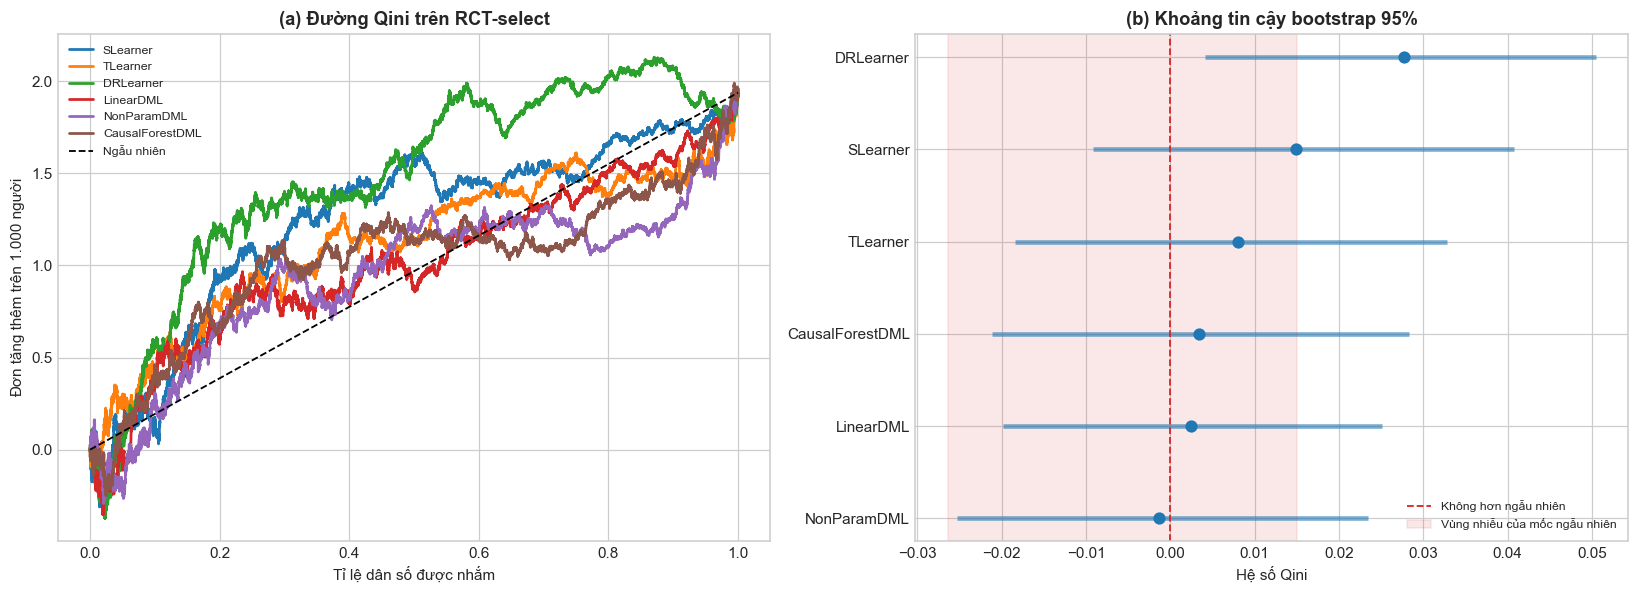

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

mau_sac = plt.cm.tab10(np.linspace(0, 1, 10))

for i, name in enumerate(OK_MODELS):
    x, g = qini_curve(y_sel, w_sel, cate_sel[name])
    axes[0].plot(x, g * 1000, label=name, color=mau_sac[i], lw=1.8)

x, g = qini_curve(y_sel, w_sel, cate_sel[OK_MODELS[0]])
axes[0].plot([0, 1], [0, g[-1] * 1000], '--', color='black', lw=1.2, label='Ngẫu nhiên')
axes[0].set_xlabel('Tỉ lệ dân số được nhắm')
axes[0].set_ylabel('Đơn tăng thêm trên 1.000 người')
axes[0].set_title('(a) Đường Qini trên RCT-select')
axes[0].legend(fontsize=8, loc='upper left')

# (b) khoảng tin cậy dạng thanh ngang
dfp = df_sel[df_sel['Mô hình'] != '— Ngẫu nhiên (mốc)'].iloc[::-1]
ypos = np.arange(len(dfp))
axes[1].hlines(ypos, dfp['Qini_lo'], dfp['Qini_hi'], color='#1f77b4', lw=3, alpha=0.6)
axes[1].plot(dfp['Qini'], ypos, 'o', color='#1f77b4', ms=7)
axes[1].axvline(0, color='#d62728', ls='--', lw=1.2, label='Không hơn ngẫu nhiên')
axes[1].axvspan(lo_rnd, hi_rnd, color='#d62728', alpha=0.10, label='Vùng nhiễu của mốc ngẫu nhiên')
axes[1].set_yticks(ypos)
axes[1].set_yticklabels(dfp['Mô hình'])
axes[1].set_xlabel('Hệ số Qini')
axes[1].set_title('(b) Khoảng tin cậy bootstrap 95%')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '15_qini_rct_select.png'), bbox_inches='tight')
plt.show()

### Bước 23 — Chọn quán quân, và kiểm tra xem lựa chọn đó có ý nghĩa không

Hai câu hỏi tách bạch, hay bị gộp làm một:

1. *Mô hình nào có Qini điểm cao nhất?* — luôn có câu trả lời, chỉ cần sắp xếp.
2. *Chênh lệch đó có vượt được nhiễu không?* — mới là câu hỏi khoa học.

Kiểm câu thứ hai bằng bootstrap **theo cặp**: trong mỗi lần lấy mẫu lại, tính hiệu Qini của quán quân
trừ Qini của từng đối thủ trên **cùng một mẫu**. Cách này khử được phần dao động chung do mẫu — thứ
tác động lên cả hai mô hình như nhau — nên nhạy hơn nhiều so với việc nhìn xem hai khoảng tin cậy
riêng lẻ có chồng lấn hay không.

In [24]:
quan_quan = df_sel[df_sel['Mô hình'] != '— Ngẫu nhiên (mốc)'].iloc[0]['Mô hình']
print(f'Qini điểm cao nhất: {quan_quan}\n')

rng_pair = np.random.RandomState(SEED)
n_sel = len(y_sel)
idx_boot = [rng_pair.randint(0, n_sel, n_sel) for _ in range(N_BOOT)]

so_sanh = []
for name in OK_MODELS:
    if name == quan_quan:
        continue
    hieu = np.array([qini_score(y_sel[i], w_sel[i], cate_sel[quan_quan][i])
                     - qini_score(y_sel[i], w_sel[i], cate_sel[name][i]) for i in idx_boot])
    lo, hi = np.percentile(hieu, [2.5, 97.5])
    so_sanh.append({'Đối thủ': name, 'Chênh lệch Qini': hieu.mean(),
                    'KTC thấp': lo, 'KTC cao': hi, 'Khác 0': bool(lo > 0 or hi < 0)})

df_ss = pd.DataFrame(so_sanh)
display(df_ss.round(4))

n_thang = int(df_ss['Khác 0'].sum())
print(f'\n{quan_quan} vượt trội có ý nghĩa thống kê so với {n_thang}/{len(df_ss)} đối thủ.')
if n_thang == 0:
    print('=> Không mô hình nào tách khỏi phần còn lại. Kết luận trung thực: các phương pháp')
    print('   KHÔNG khác biệt có ý nghĩa thống kê trên bộ dữ liệu này.')
    print('   Vẫn lấy mô hình điểm cao nhất làm quán quân để có thứ bàn giao, nhưng phải nói rõ')
    print('   lựa chọn đó nằm trong vùng nhiễu.')

Qini điểm cao nhất: DRLearner



,Đối thủ,Chênh lệch Qini,KTC thấp,KTC cao,Khác 0
0,SLearner,0.0118,-0.0114,0.0342,False
1,TLearner,0.0179,-0.0108,0.0453,False
2,LinearDML,0.0248,0.0036,0.0451,True
3,NonParamDML,0.0288,0.0039,0.0534,True
4,CausalForestDML,0.0234,-0.0056,0.0536,False



DRLearner vượt trội có ý nghĩa thống kê so với 2/5 đối thủ.


---
# Phần 5 — Độ quan trọng đặc trưng & chọn số đặc trưng

Phần này vẫn nằm **trước** khi mở holdout, vì nó kết thúc bằng một quyết định: giữ lại bao nhiêu đặc
trưng để bàn giao. Mọi quyết định đều phải xong trước Phần 6.

Điểm mấu chốt: **k không được gõ tay.** Cả vùng quét lẫn giá trị chốt đều suy ra từ dữ liệu — vùng
quét từ đường gain của mô hình, giá trị chốt từ Qini đo trên `rct_select`.

### Bước 24 — Độ quan trọng lấy từ tầng cuối của DR-Learner

DR-Learner có cấu trúc thuận tiện cho việc này: tầng cuối của nó là một mô hình hồi quy đơn giản ánh
xạ thẳng từ đặc trưng sang pseudo-outcome doubly robust. Nên độ quan trọng đọc ra ở đó là *đặc trưng
nào quyết định hiệu ứng điều trị*, chứ không phải *đặc trưng nào quyết định việc mua hàng* — hai câu
hỏi hoàn toàn khác nhau, và cái thứ nhất mới là cái đề tài cần.

Đã đặt `importance_type='gain'` ở Bước 15, lý do giải thích ở đó.

Con số cần chú ý nhất ở đây không phải top mấy, mà là **số đặc trưng có gain đúng bằng 0**. Gain
bằng 0 nghĩa là trong toàn bộ cây của tầng cuối, mô hình **chưa từng một lần chia nhánh** theo đặc
trưng đó. Dự đoán của mô hình hoàn toàn không phụ thuộc vào giá trị của chúng — đây là một ngưỡng do
dữ liệu tự vạch ra chứ không do ai chọn, và nó là cận trên tự nhiên cho vùng cần quét ở Bước 26.

In [ ]:
if 'DRLearner' in models:
    imp = pd.Series(models['DRLearner'].model.feature_importances_,
                    index=FEATS).sort_values(ascending=False)
    imp_pct = imp / imp.sum() * 100
    cum_pct = imp_pct.cumsum()
    n_dung = int((imp > 0).sum())

    print('Top 15 đặc trưng theo gain:\n')
    display(pd.DataFrame({'Gain': imp.head(15).round(1),
                          '% tổng gain': imp_pct.head(15).round(2),
                          '% tích lũy': cum_pct.head(15).round(2)}))

    print(f'\nĐặc trưng mô hình THỰC SỰ dùng (gain > 0) : {n_dung}/{len(FEATS)}')
    print(f'Đặc trưng chưa từng được chia nhánh       : {len(FEATS) - n_dung}')
    if quan_quan != 'DRLearner':
        print(f'\nLưu ý: quán quân là {quan_quan}, nhưng độ quan trọng vẫn lấy từ DR-Learner '
              'vì tầng cuối của nó ánh xạ thẳng đặc trưng sang pseudo-outcome.')
else:
    imp, n_dung = None, 0
    print('DR-Learner không huấn luyện được — bỏ qua phần độ quan trọng')

Top 15 đặc trưng theo gain:



,Gain,% tổng gain,% tích lũy
f31,3398.8,17.76,17.76
f35,1735.3,9.07,26.83
f2,1328.7,6.94,33.77
f3,965.7,5.05,38.81
f4,946.4,4.95,43.76
f10,882.9,4.61,48.37
fe_ratio_f1_f2,882.7,4.61,52.98
f64,847.3,4.43,57.41
f68,686.4,3.59,61.00
f1,645.8,3.37,64.37



Đặc trưng mô hình THỰC SỰ dùng (gain > 0) : 41/76
Đặc trưng chưa từng được chia nhánh       : 35


### Bước 25 — Biểu đồ độ quan trọng và đường gain tích lũy

Panel bên phải là thứ quyết định vùng quét ở bước sau: đường gain tích lũy cho thấy tín hiệu tập
trung vào bao nhiêu đặc trưng đầu, và nó phẳng hẳn ra từ đâu.

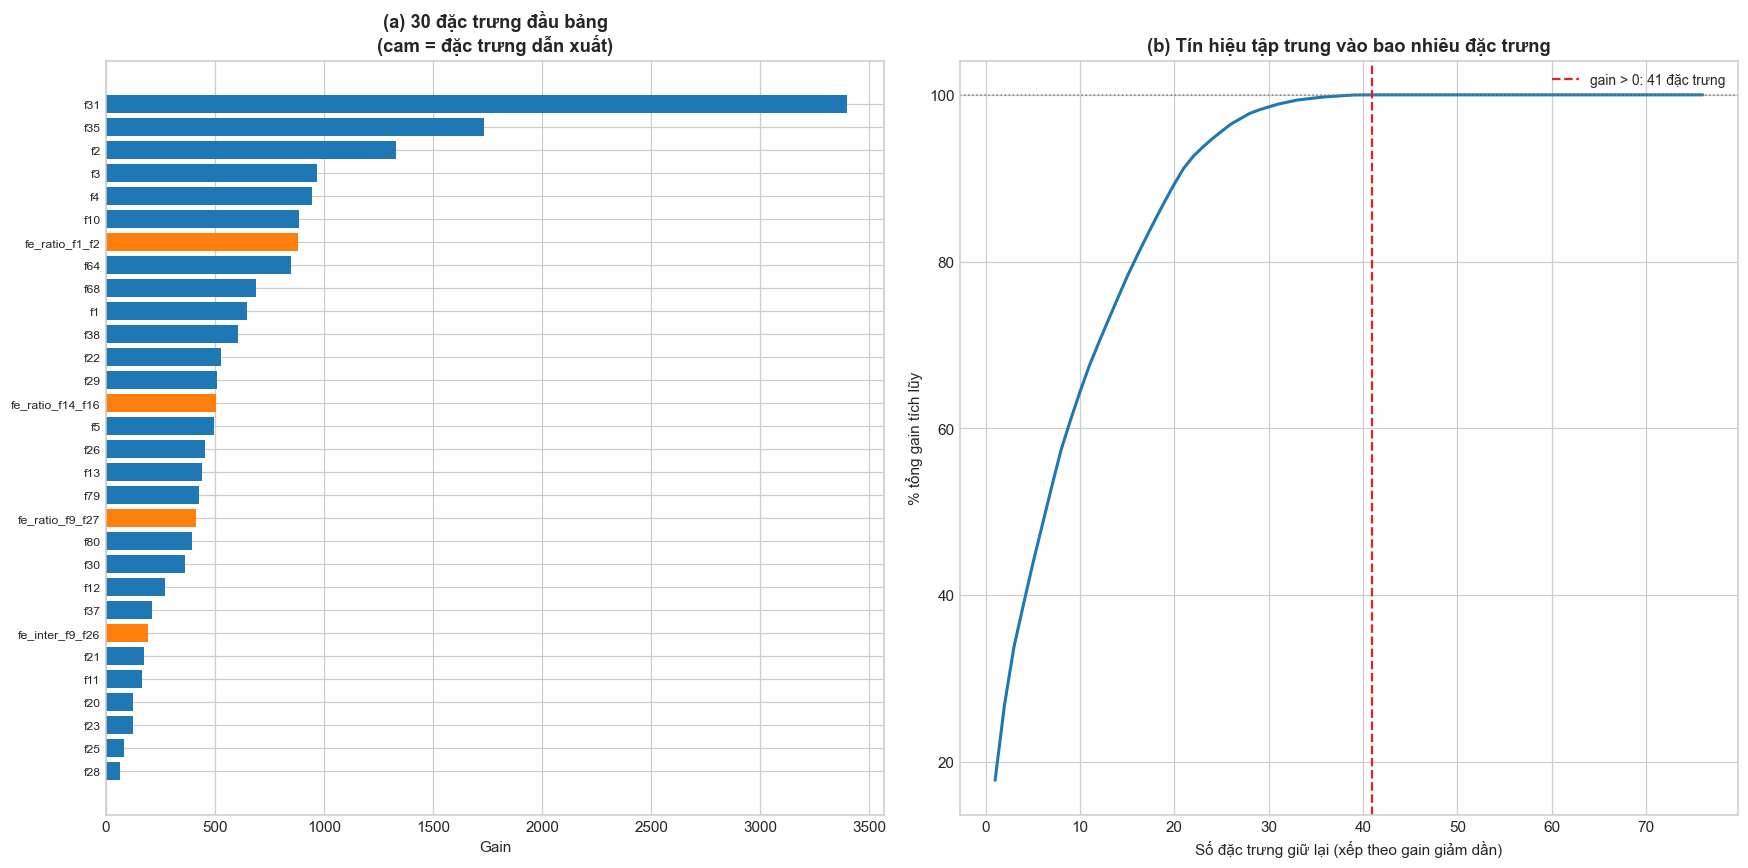

4/7 đặc trưng dẫn xuất lọt vào 30 đầu bảng


In [ ]:
if imp is not None:
    n_ve = min(30, n_dung)          # chỉ để nhìn cho vừa khung, không quyết định gì
    top_ve = imp.head(n_ve)[::-1]
    la_dan_xuat = [c.startswith('fe_') for c in top_ve.index]

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].barh(range(len(top_ve)), top_ve.values,
                 color=['#ff7f0e' if d else '#1f77b4' for d in la_dan_xuat])
    axes[0].set_yticks(range(len(top_ve)))
    axes[0].set_yticklabels(top_ve.index, fontsize=8)
    axes[0].set_xlabel('Gain')
    axes[0].set_title(f'(a) {n_ve} đặc trưng đầu bảng\n(cam = đặc trưng dẫn xuất)')

    axes[1].plot(range(1, len(imp) + 1), cum_pct.values, '-', color='#1f77b4', lw=2)
    axes[1].axvline(n_dung, color='#d62728', ls='--', lw=1.5,
                    label=f'gain > 0: {n_dung} đặc trưng')
    axes[1].axhline(100, color='#7f7f7f', ls=':', lw=1)
    axes[1].set_xlabel('Số đặc trưng giữ lại (xếp theo gain giảm dần)')
    axes[1].set_ylabel('% tổng gain tích lũy')
    axes[1].set_title('(b) Tín hiệu tập trung vào bao nhiêu đặc trưng')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '16_do_quan_trong_dac_trung.png'), bbox_inches='tight')
    plt.show()

    n_fe = sum(c.startswith('fe_') for c in imp.head(n_ve).index)
    print(f'{n_fe}/7 đặc trưng dẫn xuất lọt vào {n_ve} đầu bảng')

### Bước 26 — Quét k: bỏ bớt đặc trưng tới đâu thì mô hình còn tốt?

Câu hỏi đặt cho đúng là *"giữ lại bao nhiêu đặc trưng thì mô hình vẫn còn tốt"*, và **k phải do dữ
liệu trả lời**, không phải do ai gõ vào.

**Lưới quét dựng từ chính đường gain**, không có giá trị nào gõ tay:

- Cận trên: `n_dung` — số đặc trưng có gain > 0. Vượt qua mốc này là thêm những cột mô hình không hề
  đọc tới, quét thêm cũng vô nghĩa.
- Cận dưới: k nhỏ nhất đạt 50% tổng gain. Dưới mức đó thì đã vứt quá nửa tín hiệu, không cần thử.
- Ở giữa chia đều 8 điểm, cộng thêm mốc đầy đủ để có mặt bằng so sánh.

Với mỗi k: huấn luyện lại DR-Learner chỉ trên k đặc trưng đầu bảng, rồi đo Qini kèm khoảng tin cậy
bootstrap **trên `rct_select`**.

**Cắt cột thì giữ nguyên thứ tự `FEATS` gốc**, không xếp lại theo gain. Nghe như tiểu tiết nhưng
không phải: LightGBM khi gặp hai điểm chia ngang tài sẽ lấy đặc trưng đứng trước trong danh sách, mà
nhãn DR-score nhiễu nặng nên thế ngang tài xảy ra liên tục. Xếp lại cột — một hoán vị chẳng mang
thông tin gì — cũng đủ làm mô hình khác đi. Lần chạy đầu tôi xếp theo gain và mốc `k = 76` cho Qini
`0,024` trong khi chính mô hình đó ở Bước 20 cho `0,028`; mốc tham chiếu bị hạ thấp kéo theo toàn bộ
so sánh sai và k chốt trở thành kết luận của một phép đo hỏng. Ô lệnh có sẵn một `assert` ở mốc đầy
đủ để lỗi này không tái diễn âm thầm.

Ba điều cần nói trước:

- **Vì sao đo trên `rct_select` chứ không phải holdout.** Đây là bước *ra quyết định*: chọn bộ đặc
  trưng nào để bàn giao. Đo nó trên holdout rồi chọn theo kết quả thì đúng bằng dùng holdout làm tập
  validation, và toàn bộ con số ở Phần 6 mất giá trị.
- **Bảng xếp hạng đặc trưng đến từ đâu.** Từ mô hình học trên Train + Val, không dính gì tới
  `rct_select`. Nên việc xếp hạng không rò rỉ thông tin của tập dùng để chấm điểm.
- **Siêu tham số giữ nguyên** bộ đã tinh chỉnh cho 76 đặc trưng. Tinh chỉnh lại cho từng k sẽ công
  bằng hơn nhưng tốn gấp nhiều lần, và bản thân việc đó cũng là một dạng chọn lọc trên `rct_select`.
  Ghi nhận đây là một giới hạn: bản rút gọn có thể đang bị thiệt đôi chút.

Chạy khoảng 10–15 phút.

In [ ]:
if imp is not None:
    # --- lưới k dựng từ đường gain, không gõ tay giá trị nào ---
    k_min = int((cum_pct < 50).sum() + 1)        # k nhỏ nhất đạt 50% tổng gain
    K_GRID = sorted(set(np.linspace(k_min, n_dung, 8).round().astype(int).tolist()
                        + [len(FEATS)]))

    print(f'Cận dưới (đạt 50% gain) : {k_min}')
    print(f'Cận trên (gain > 0)     : {n_dung}')
    print(f'Lưới quét               : {K_GRID}\n')

    idx_row = lay_mau(N_FIT['DRLearner'])

    # Qini của bản đầy đủ trên từng mẫu bootstrap — tính một lần, dùng lại cho mọi k
    q_full_boot = np.array([qini_score(y_sel[i], w_sel[i], cate_sel['DRLearner'][i])
                            for i in idx_boot])

    quet, cate_theo_k, mo_hinh_theo_k = [], {}, {}
    for k in K_GRID:
        # Chọn TẬP k đặc trưng theo gain, nhưng giữ nguyên THỨ TỰ cột của FEATS.
        # Xếp lại cột theo gain là hoán vị không mang thông tin, vậy mà đủ để LightGBM
        # phá thế hòa khác đi và cho ra mô hình khác — xem markdown ở trên.
        giu = set(imp.head(k).index)
        fk = [f for f in FEATS if f in giu]
        ik = [FEATS.index(f) for f in fk]

        t0 = time.time()
        m_k = build_model('DRLearner', BEST['DRLearner']['params']).fit(
            X_full[np.ix_(idx_row, ik)], W_full[idx_row], Y_full[idx_row])
        c_k = m_k.predict_cate(X_sel[:, ik])
        giay = time.time() - t0

        q, lo, hi, _ = bootstrap_ci(qini_score, y_sel, w_sel, c_k)
        hieu = q_full_boot - np.array([qini_score(y_sel[i], w_sel[i], c_k[i])
                                       for i in idx_boot])
        h_lo, h_hi = np.percentile(hieu, [2.5, 97.5])

        # Tự kiểm: ở mốc đầy đủ, mô hình quét PHẢI trùng khít mô hình gốc ở Bước 18.
        # Lệch ở đây nghĩa là cột bị xếp lại ở đâu đó, và mọi so sánh phía dưới hỏng theo.
        if k == len(FEATS):
            lech = float(np.abs(c_k - cate_sel['DRLearner']).max())
            assert lech < 1e-9, (f'Mốc k={k} lệch {lech:.2e} so với mô hình gốc ở Bước 18 '
                                 '— kiểm tra lại thứ tự cột')

        cate_theo_k[k], mo_hinh_theo_k[k] = c_k, m_k
        quet.append({'k': k, 'Qini': q, 'Qini_lo': lo, 'Qini_hi': hi,
                     'Hiệu so với đầy đủ': hieu.mean(), 'Hiệu_lo': h_lo, 'Hiệu_hi': h_hi,
                     '% gain giữ lại': float(cum_pct.iloc[k - 1]), 'Giây': giay})
        print(f'  k = {k:>3} | Qini = {fmt_ci(q, lo, hi)} | '
              f'hiệu so với đầy đủ = {hieu.mean():+.4f} [{h_lo:+.4f} – {h_hi:+.4f}] | {giay:.0f}s')

    df_quet = pd.DataFrame(quet)

Cận dưới (đạt 50% gain) : 7
Cận trên (gain > 0)     : 41
Lưới quét               : [7, 12, 17, 22, 26, 31, 36, 41, 76]

  k =   7 | Qini = 0.008 [-0.016 – 0.032] | hiệu so với đầy đủ = +0.0195 [+0.0016 – +0.0379] | 20s
  k =  12 | Qini = 0.005 [-0.017 – 0.028] | hiệu so với đầy đủ = +0.0227 [+0.0054 – +0.0400] | 23s
  k =  17 | Qini = 0.011 [-0.013 – 0.035] | hiệu so với đầy đủ = +0.0163 [-0.0006 – +0.0337] | 25s
  k =  22 | Qini = 0.012 [-0.014 – 0.037] | hiệu so với đầy đủ = +0.0150 [-0.0013 – +0.0312] | 27s
  k =  26 | Qini = 0.013 [-0.010 – 0.037] | hiệu so với đầy đủ = +0.0139 [-0.0020 – +0.0292] | 27s
  k =  31 | Qini = 0.011 [-0.014 – 0.034] | hiệu so với đầy đủ = +0.0165 [+0.0018 – +0.0311] | 32s
  k =  36 | Qini = 0.021 [-0.003 – 0.044] | hiệu so với đầy đủ = +0.0058 [-0.0077 – +0.0174] | 30s
  k =  41 | Qini = 0.022 [-0.002 – 0.044] | hiệu so với đầy đủ = +0.0052 [-0.0085 – +0.0187] | 33s
  k =  76 | Qini = 0.028 [0.004 – 0.050] | hiệu so với đầy đủ = +0.0000 [+0.0000 – +0.00

### Bước 27 — Quy tắc chốt k

Ba điều kiện, tất cả đo trên `rct_select`. **k chốt là giá trị nhỏ nhất thỏa mãn cả ba.**

| Điều kiện | Ý nghĩa | Cách kiểm |
|---|---|---|
| **1. Còn hơn ngẫu nhiên** | Bản rút gọn vẫn giữ được thứ khiến mô hình đáng báo cáo | KTC Qini không chứa 0 |
| **2. Bền** | Điều kiện 1 đúng ở k này **và ở mọi k lớn hơn** trong lưới | không mức nào phía trên rơi lại |
| **3. Không tệ hơn bản đầy đủ** | Cú cắt không gây thiệt hại đo được | KTC của hiệu chứa 0 |

Điều kiện 1 là chỗ dễ làm thiếu. Chỉ hỏi *"cú giảm có ý nghĩa không"* thì với khoảng tin cậy rộng thế
này hầu như cú giảm nào cũng "không có ý nghĩa", kể cả cú giảm làm mô hình rơi xuống ngang mức ngẫu
nhiên.

Điều kiện 2 khó thấy hơn. Đường Qini theo k rất nhiễu — mỗi điểm là một mô hình huấn luyện lại, khoảng
tin cậy chồng lên nhau. Trên một đường như vậy, **lấy k nhỏ nhất vượt ngưỡng chính là đi chọn đúng cái
đỉnh nhiễu thấp nhất**: một mức k tình cờ nhô lên trong khi các mức lân cận cao hơn lại trượt. Đó
không phải tín hiệu, và bàn giao nó cho DE là bàn giao một sự may mắn. Yêu cầu tính bền buộc phải thấy
một *vùng* ổn định thay vì một *điểm* đẹp.

Nếu không k nào thỏa mãn cả ba thì kết luận là **không cắt được** — giữ nguyên toàn bộ đặc trưng. Đó
cũng là một câu trả lời hợp lệ, tốt hơn nhiều so với cắt bừa rồi bàn giao một mô hình đã mất tín hiệu.

In [ ]:
if imp is not None:
    df_quet = df_quet.sort_values('k').reset_index(drop=True)
    df_quet['Hơn ngẫu nhiên'] = df_quet['Qini_lo'] > 0
    # bền: điều kiện 1 đúng ở k này VÀ ở mọi k lớn hơn — quét ngược từ cuối lên
    df_quet['Bền'] = df_quet['Hơn ngẫu nhiên'][::-1].cummin()[::-1].astype(bool)
    df_quet['Không tệ hơn bản đầy đủ'] = df_quet['Hiệu_lo'] <= 0
    df_quet['Đạt'] = df_quet['Bền'] & df_quet['Không tệ hơn bản đầy đủ']

    hien = df_quet[['k', '% gain giữ lại', 'Qini', 'Qini_lo', 'Qini_hi',
                    'Hiệu so với đầy đủ', 'Hơn ngẫu nhiên', 'Bền',
                    'Không tệ hơn bản đầy đủ', 'Đạt', 'Giây']].copy()
    hien['% gain giữ lại'] = hien['% gain giữ lại'].round(1)
    hien['Giây'] = hien['Giây'].round(0)
    display(hien.round(4))

    dat = df_quet[df_quet['Đạt']]
    if len(dat):
        K_CHOT = int(dat['k'].min())
        ly_do = 'k nhỏ nhất thỏa mãn cả ba điều kiện (có tính bền)'
    else:
        K_CHOT = len(FEATS)
        ly_do = 'không k nào thỏa mãn cả ba điều kiện — giữ nguyên toàn bộ đặc trưng'

    roi_lai = df_quet[df_quet['Hơn ngẫu nhiên'] & ~df_quet['Bền']]['k'].tolist()
    if roi_lai:
        print(f'Bị loại vì không bền (có mức k lớn hơn rơi lại dưới ngưỡng): {roi_lai}')

    r = df_quet[df_quet['k'] == K_CHOT].iloc[0]
    print(f'\n=> k chốt: {K_CHOT}  ({ly_do})')
    print(f'   Qini = {fmt_ci(r.Qini, r.Qini_lo, r.Qini_hi)} | '
          f'giữ lại {r["% gain giữ lại"]:.1f}% tổng gain')
    print(f'   Bỏ đi {len(FEATS) - K_CHOT}/{len(FEATS)} đặc trưng')

    # FEAT_CHOT luôn theo thứ tự FEATS gốc, khớp đúng cách mô hình được huấn luyện
    giu = set(imp.head(K_CHOT).index)
    FEAT_CHOT = [f for f in FEATS if f in giu]
    IDX_CHOT = [FEATS.index(f) for f in FEAT_CHOT]
    model_rut_gon = mo_hinh_theo_k[K_CHOT] if K_CHOT < len(FEATS) else None
else:
    K_CHOT, FEAT_CHOT, IDX_CHOT = len(FEATS), list(FEATS), list(range(len(FEATS)))
    model_rut_gon, df_quet = None, None
    print('Không có bảng độ quan trọng — giữ nguyên toàn bộ đặc trưng')

,k,% gain giữ lại,Qini,Qini_lo,Qini_hi,Hiệu so với đầy đủ,Hơn ngẫu nhiên,Bền,Không tệ hơn bản đầy đủ,Đạt,Giây
0,7,53.0,0.0078,-0.0159,0.0318,0.0195,False,False,False,False,20.0
1,12,70.3,0.0045,-0.0172,0.0276,0.0227,False,False,False,False,23.0
2,17,82.9,0.0108,-0.0129,0.0352,0.0163,False,False,True,False,25.0
3,22,92.6,0.0121,-0.0142,0.0372,0.0150,False,False,True,False,27.0
4,26,96.5,0.0131,-0.0103,0.0373,0.0139,False,False,True,False,27.0
5,31,98.9,0.0105,-0.0140,0.0339,0.0165,False,False,False,False,32.0
6,36,99.8,0.0215,-0.0032,0.0441,0.0058,False,False,True,False,30.0
7,41,100.0,0.0224,-0.0021,0.0442,0.0052,False,False,True,False,33.0
8,76,100.0,0.0277,0.0041,0.0504,0.0000,True,True,True,True,40.0



=> k chốt: 76  (k nhỏ nhất thỏa mãn cả ba điều kiện (có tính bền))
   Qini = 0.028 [0.004 – 0.050] | giữ lại 100.0% tổng gain
   Bỏ đi 0/76 đặc trưng


### Bước 28 — Biểu đồ Qini theo k

Đường này là bằng chứng trực quan cho quyết định vừa rồi: Qini bám ngang khi cắt bớt đặc trưng thừa,
rồi tụt xuống vùng nhiễu khi cắt vào phần mang tín hiệu. Điểm gãy nằm ở đâu là do dữ liệu, không do
ai chọn.

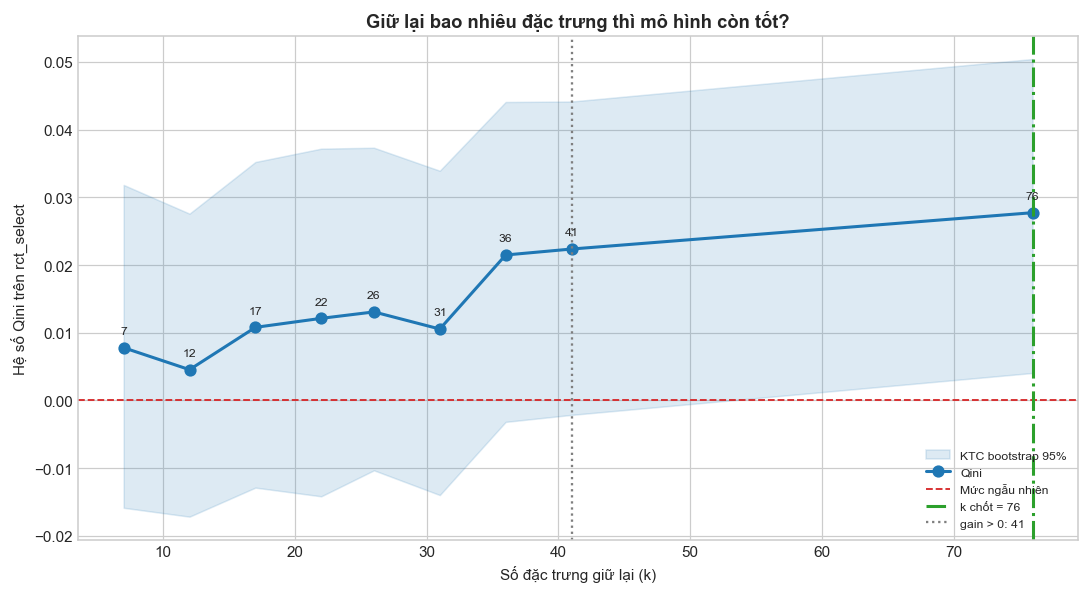

In [ ]:
if df_quet is not None:
    fig, ax = plt.subplots(figsize=(10, 5.5))

    ax.fill_between(df_quet['k'], df_quet['Qini_lo'], df_quet['Qini_hi'],
                    color='#1f77b4', alpha=0.15, label='KTC bootstrap 95%')
    ax.plot(df_quet['k'], df_quet['Qini'], 'o-', color='#1f77b4', lw=2, ms=7, label='Qini')
    ax.axhline(0, color='#d62728', ls='--', lw=1.2, label='Mức ngẫu nhiên')
    ax.axvline(K_CHOT, color='#2ca02c', ls='-.', lw=2, label=f'k chốt = {K_CHOT}')
    ax.axvline(n_dung, color='#7f7f7f', ls=':', lw=1.5, label=f'gain > 0: {n_dung}')

    for _, r in df_quet.iterrows():
        ax.annotate(f'{int(r.k)}', (r.k, r.Qini), textcoords='offset points',
                    xytext=(0, 9), ha='center', fontsize=8)

    ax.set_xlabel('Số đặc trưng giữ lại (k)')
    ax.set_ylabel('Hệ số Qini trên rct_select')
    ax.set_title('Giữ lại bao nhiêu đặc trưng thì mô hình còn tốt?')
    ax.legend(fontsize=8, loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '20_quet_so_dac_trung.png'), bbox_inches='tight')
    plt.show()

### Bước 29 — Ablation lúc phục vụ: Redis thật sự cần bao nhiêu đặc trưng?

Bước 26 hỏi *"huấn luyện lại với k đặc trưng thì sao"* và trả lời: không cắt được. Nhưng đó **không
phải câu hỏi của bài toán triển khai**, và mentor đã nêu rõ câu đúng ở buổi catch-up tuần 1:

> *"...đánh giá tầm quan trọng của đặc trưng để xem khi bớt đi một số trường thông tin thì độ chính
> xác của mô hình có bị ảnh hưởng nhiều hay không. Thực tế, anh nghĩ chỉ cần tối ưu và giữ lại khoảng
> 25 đặc trưng quan trọng nhất để đưa lên Redis là đủ hiệu quả."*

Redis phục vụ ở **lúc `predict`**, và đó là hai thời điểm khác nhau đối với DR-Learner:

| Tầng | Làm gì | Chạy lúc nào |
|---|---|---|
| Tầng 1 — propensity + hai mô hình outcome | Dựng nhãn DR-score | **Chỉ lúc huấn luyện** |
| Tầng 2 — hồi quy pseudo-outcome | Cho ra CATE | **Lúc `predict`** |

Bước 26 cắt đặc trưng ở cả hai tầng, nên nhãn DR-score xấu đi và mô hình kém theo. Còn ở đây mô hình
**giữ nguyên không huấn luyện lại**, chỉ bớt đầu vào lúc dự đoán — tầng 1 đã xong việc từ lâu nên
không bị ảnh hưởng gì.

**Cách làm:** đặc trưng ngoài top-k được thay bằng **giá trị mặc định** (trung vị trên Train + Val),
đúng thứ mà `feature_contract.json` bảo AI Service dùng cho khách hàng mới chưa có dữ liệu. Nói cách
khác, đây là mô phỏng chính xác tình huống *"Redis chỉ có k đặc trưng này"*.

**Một mốc biết trước đáp án:** 35 đặc trưng có gain = 0, tức cây chưa từng chia nhánh theo chúng, nên
giá trị của chúng không thể ảnh hưởng tới đầu ra. Vậy ở `k = 41` sai lệch dự đoán phải **đúng bằng 0**.
Đây không phải kết luận thống kê mà là một đẳng thức, và ô lệnh có `assert` để xác nhận.

In [72]:
if imp is not None:
    # Đo trên ĐÚNG mô hình sẽ bàn giao, nếu không contract mô tả một mô hình khác
    m_phuc_vu = models[quan_quan]
    cate_goc = cate_sel[quan_quan]
    if quan_quan != 'DRLearner':
        print(f'Lưu ý: thứ tự bỏ đặc trưng lấy từ gain của DR-Learner, nhưng ablation đo trên '
              f'{quan_quan} — mô hình thật sự được bàn giao. Bảng gain chỉ đóng vai trò đề xuất '
              'thứ tự, phán quyết vẫn là Qini đo được.\n')

    # giá trị mặc định = trung vị trên Train + Val, khớp đúng feature_contract.json
    MAC_DINH = full[FEATS].median().values.astype(np.float32)

    def du_doan_voi_k(k):
        '''Dự đoán khi Redis chỉ có k đặc trưng đầu bảng, phần còn lại lấy giá trị mặc định.'''
        giu = set(imp.head(k).index)
        thay = np.array([f not in giu for f in FEATS])
        Xk = X_sel.copy()
        Xk[:, thay] = MAC_DINH[thay]
        return m_phuc_vu.predict_cate(Xk)

    # Qini của mô hình bàn giao trên từng mẫu bootstrap — mốc để so hiệu
    q_ref_boot = (q_full_boot if quan_quan == 'DRLearner' else
                  np.array([qini_score(y_sel[i], w_sel[i], cate_goc[i]) for i in idx_boot]))

    # lưới quét: cùng cách dựng như Bước 26, cận trên là số đặc trưng có gain > 0
    K_GRID_PV = sorted(set(np.linspace(k_min, n_dung, 8).round().astype(int).tolist()
                           + [len(FEATS)]))
    print(f'Lưới quét: {K_GRID_PV}\n')

    quet_pv, cate_pv = [], {}
    for k in K_GRID_PV:
        s = du_doan_voi_k(k)
        lech = float(np.abs(s - cate_goc).max())

        # Mốc biết trước đáp án, chỉ đúng khi mô hình bàn giao chính là DR-Learner:
        # từ n_dung trở lên không còn đặc trưng nào có gain > 0 bị thay, nên dự đoán phải trùng khít.
        if quan_quan == 'DRLearner' and k >= n_dung:
            assert lech < 1e-9, (f'k={k} ≥ số đặc trưng có gain>0 ({n_dung}) mà vẫn lệch '
                                 f'{lech:.2e} — mâu thuẫn, kiểm tra lại')

        q, lo, hi, _ = bootstrap_ci(qini_score, y_sel, w_sel, s)
        hieu = q_ref_boot - np.array([qini_score(y_sel[i], w_sel[i], s[i]) for i in idx_boot])
        h_lo, h_hi = np.percentile(hieu, [2.5, 97.5])

        cate_pv[k] = s
        quet_pv.append({'k': k, '% gain giữ lại': float(cum_pct.iloc[k - 1]),
                        'Qini': q, 'Qini_lo': lo, 'Qini_hi': hi,
                        'Hiệu so với đầy đủ': hieu.mean(), 'Hiệu_lo': h_lo, 'Hiệu_hi': h_hi,
                        'Lệch dự đoán': lech})
        print(f'  k = {k:>3} | Qini = {fmt_ci(q, lo, hi)} | lệch dự đoán = {lech:.2e}')

    df_pv = pd.DataFrame(quet_pv).sort_values('k').reset_index(drop=True)
else:
    df_pv = None
    print('Không có bảng độ quan trọng — bỏ qua')

Lưới quét: [7, 12, 17, 22, 26, 31, 36, 41, 76]

  k =   7 | Qini = 0.035 [0.007 – 0.057] | lệch dự đoán = 6.25e-01
  k =  12 | Qini = 0.016 [-0.012 – 0.037] | lệch dự đoán = 3.25e-01
  k =  17 | Qini = 0.021 [-0.005 – 0.043] | lệch dự đoán = 2.99e-01
  k =  22 | Qini = 0.016 [-0.009 – 0.037] | lệch dự đoán = 2.70e-01
  k =  26 | Qini = 0.019 [-0.004 – 0.043] | lệch dự đoán = 2.51e-01
  k =  31 | Qini = 0.024 [-0.000 – 0.048] | lệch dự đoán = 2.65e-02
  k =  36 | Qini = 0.028 [0.004 – 0.050] | lệch dự đoán = 1.37e-02
  k =  41 | Qini = 0.028 [0.004 – 0.050] | lệch dự đoán = 0.00e+00
  k =  76 | Qini = 0.028 [0.004 – 0.050] | lệch dự đoán = 0.00e+00


### Bước 30 — Chốt số đặc trưng đưa lên Redis

Dùng lại **đúng ba điều kiện** của Bước 27 để hai kết luận so sánh được với nhau, không phải một bên
chặt một bên lỏng:

1. Còn hơn ngẫu nhiên — KTC Qini không chứa 0
2. Bền — điều kiện 1 đúng ở k này và ở mọi k lớn hơn
3. Không tệ hơn bản đầy đủ — KTC của hiệu chứa 0

Khác biệt duy nhất so với Bước 27 là ở đây mô hình không bị huấn luyện lại, nên `k = n_dung` chắc chắn
đạt cả ba (sai lệch bằng 0). Câu hỏi thật là **xuống được tới đâu nữa**.

In [100]:
if df_pv is not None:
    df_pv['Hơn ngẫu nhiên'] = df_pv['Qini_lo'] > 0
    df_pv['Bền'] = df_pv['Hơn ngẫu nhiên'][::-1].cummin()[::-1].astype(bool)
    df_pv['Không tệ hơn bản đầy đủ'] = df_pv['Hiệu_lo'] <= 0
    df_pv['Đạt'] = df_pv['Bền'] & df_pv['Không tệ hơn bản đầy đủ']

    hien = df_pv[['k', '% gain giữ lại', 'Qini', 'Qini_lo', 'Qini_hi', 'Lệch dự đoán',
                  'Hơn ngẫu nhiên', 'Bền', 'Không tệ hơn bản đầy đủ', 'Đạt']].copy()
    hien['% gain giữ lại'] = hien['% gain giữ lại'].round(1)
    display(hien.round(4))

     # Mốc 1 — tối thiểu thống kê
    dat_pv = df_pv[df_pv['Đạt']]
    K_TOI_THIEU = int(dat_pv['k'].min()) if len(dat_pv) else len(FEATS)

    # Mốc 2 — an toàn tuyệt đối: lấy từ số ĐO ĐƯỢC, không suy từ gain
    khong_doi = df_pv[df_pv['Lệch dự đoán'] < 1e-9]
    K_AN_TOAN = int(khong_doi['k'].min()) if len(khong_doi) else len(FEATS)

    UU_TIEN_AN_TOAN = True
    K_REDIS = K_AN_TOAN if UU_TIEN_AN_TOAN else K_TOI_THIEU
    ly_do_redis = ('mốc an toàn tuyệt đối — sai lệch dự đoán đo được bằng 0'
                   if UU_TIEN_AN_TOAN else 'mốc tối thiểu thống kê')

    print(f'\nTối thiểu thống kê : {K_TOI_THIEU} | An toàn tuyệt đối : {K_AN_TOAN}')


    giu_r = set(imp.head(K_REDIS).index)
    FEAT_REDIS = [f for f in FEATS if f in giu_r]          # theo thứ tự FEATS gốc
    FEAT_MAC_DINH = [f for f in FEATS if f not in giu_r]

    r = df_pv[df_pv['k'] == K_REDIS].iloc[0]
    print(f'\n=> Redis cần {K_REDIS}/{len(FEATS)} đặc trưng  ({ly_do_redis})')
    print(f'   Qini = {fmt_ci(r.Qini, r.Qini_lo, r.Qini_hi)}  '
          f'(bản đầy đủ: {fmt_ci(*df_pv[df_pv.k == len(FEATS)][["Qini","Qini_lo","Qini_hi"]].iloc[0])})')
    print(f'   Sai lệch dự đoán so với bản đầy đủ: {r["Lệch dự đoán"]:.2e}')
    print(f'   {len(FEAT_MAC_DINH)} đặc trưng còn lại AI Service điền giá trị mặc định')
    print(f'\n   Mentor gợi ý khoảng 25 — dữ liệu cho ra {K_REDIS}.')
else:
    K_REDIS, FEAT_REDIS, FEAT_MAC_DINH = len(FEATS), list(FEATS), []
    ly_do_redis = 'không quét'

,k,% gain giữ lại,Qini,Qini_lo,Qini_hi,Lệch dự đoán,Hơn ngẫu nhiên,Bền,Không tệ hơn bản đầy đủ,Đạt
0,7,53.0,0.0348,0.0069,0.0566,0.6249,True,False,True,False
1,12,70.3,0.0159,-0.0120,0.0368,0.3249,False,False,True,False
2,17,82.9,0.0214,-0.0049,0.0433,0.2994,False,False,True,False
3,22,92.6,0.0157,-0.0087,0.0374,0.2700,False,False,False,False
4,26,96.5,0.0192,-0.0042,0.0426,0.2513,False,False,True,False
5,31,98.9,0.0239,-0.0001,0.0481,0.0265,False,False,True,False
6,36,99.8,0.0280,0.0039,0.0500,0.0137,True,True,True,True
7,41,100.0,0.0277,0.0041,0.0504,0.0000,True,True,True,True
8,76,100.0,0.0277,0.0041,0.0504,0.0000,True,True,True,True



Tối thiểu thống kê : 36 | An toàn tuyệt đối : 41

=> Redis cần 41/76 đặc trưng  (mốc an toàn tuyệt đối — sai lệch dự đoán đo được bằng 0)
   Qini = 0.028 [0.004 – 0.050]  (bản đầy đủ: 0.028 [0.004 – 0.050])
   Sai lệch dự đoán so với bản đầy đủ: 0.00e+00
   35 đặc trưng còn lại AI Service điền giá trị mặc định

   Mentor gợi ý khoảng 25 — dữ liệu cho ra 41.


### Bước 31 — Hai kiểu ablation cạnh nhau

Hai đường trả lời hai câu hỏi khác nhau, và chênh lệch giữa chúng chính là phần đóng góp của tầng
nuisance — thứ chỉ tồn tại lúc huấn luyện.

- **Huấn luyện lại** (Bước 26): cắt đặc trưng ở cả hai tầng, nhãn DR-score xấu đi theo
- **Lúc phục vụ** (Bước 29): mô hình giữ nguyên, chỉ bớt đầu vào

Đường "lúc phục vụ" nằm cao hơn ở mọi k là bằng chứng trực tiếp cho luận điểm đó.

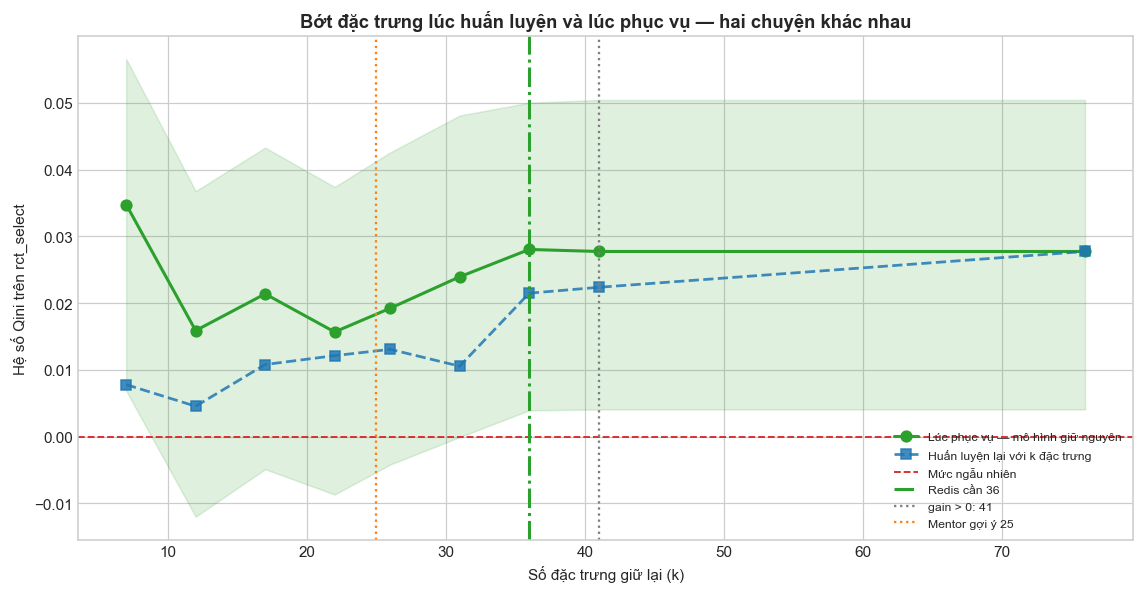

In [74]:
if df_pv is not None:
    fig, ax = plt.subplots(figsize=(10.5, 5.5))

    ax.fill_between(df_pv['k'], df_pv['Qini_lo'], df_pv['Qini_hi'],
                    color='#2ca02c', alpha=0.15)
    ax.plot(df_pv['k'], df_pv['Qini'], 'o-', color='#2ca02c', lw=2, ms=7,
            label='Lúc phục vụ — mô hình giữ nguyên')
    ax.plot(df_quet['k'], df_quet['Qini'], 's--', color='#1f77b4', lw=1.8, ms=6, alpha=0.85,
            label='Huấn luyện lại với k đặc trưng')

    ax.axhline(0, color='#d62728', ls='--', lw=1.2, label='Mức ngẫu nhiên')
    ax.axvline(K_REDIS, color='#2ca02c', ls='-.', lw=2, label=f'Redis cần {K_REDIS}')
    ax.axvline(n_dung, color='#7f7f7f', ls=':', lw=1.5, label=f'gain > 0: {n_dung}')
    ax.axvline(25, color='#ff7f0e', ls=':', lw=1.5, label='Mentor gợi ý 25')

    ax.set_xlabel('Số đặc trưng giữ lại (k)')
    ax.set_ylabel('Hệ số Qini trên rct_select')
    ax.set_title('Bớt đặc trưng lúc huấn luyện và lúc phục vụ — hai chuyện khác nhau')
    ax.legend(fontsize=8, loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '21_ablation_phuc_vu.png'), bbox_inches='tight')
    plt.show()

---
# Phần 6 — RCT-holdout: chạy đúng một lần

> ## ⚠️ Điểm không quay lại
>
> Từ ô lệnh dưới đây trở đi, tập `rct_holdout` được mở ra. **Không được sửa mô hình, không được đổi
> siêu tham số, không được đổi bộ đặc trưng sau khi nhìn thấy những con số này.** Nếu lỡ làm vậy thì
> kết quả mất giá trị khoa học và cách duy nhất để cứu là chia lại dữ liệu từ notebook 02.
>
> Mọi quyết định đã chốt xong ở Phần 4 và Phần 5. Phần này chỉ đo và báo cáo.

### Bước 32 — Nạp holdout và dự đoán

In [75]:
rct_hold = pd.read_parquet(os.path.join(DATA_DIR, 'rct_holdout.parquet'))

y_hold = rct_hold['label'].values
w_hold = rct_hold['is_treat'].values
X_hold = rct_hold[FEATS].values.astype(np.float32)

cate_hold = {name: models[name].predict_cate(X_hold) for name in OK_MODELS}

print(f'RCT-holdout: {len(rct_hold):,} dòng | treat {w_hold.mean()*100:.2f}% '
      f'| mua {y_hold.mean()*100:.2f}%')
print(f'Đã chấm điểm {len(cate_hold)} mô hình')

RCT-holdout: 90,835 dòng | treat 52.12% | mua 3.52%
Đã chấm điểm 6 mô hình


### Bước 33 — Bảng benchmark cuối

Đây là bảng chính của cả đề tài. Ba cột metric đầu đo khả năng xếp hạng; cột ATE là phép kiểm tra
xem mô hình có lệch hệ thống không; hai cột cuối là chi phí.

Cột `Dòng HL` phải đọc kèm: `CausalForestDML` học trên ít dữ liệu hơn hẳn nên **không so ngang hàng
được** với phần còn lại. Nếu nó xếp cuối thì chưa chắc do phương pháp kém.

In [76]:
ket_qua_hold = []
boot_hold = {}

for name in OK_MODELS:
    s = cate_hold[name]
    q, q_lo, q_hi, q_vals = bootstrap_ci(qini_score, y_hold, w_hold, s)
    a, a_lo, a_hi, _ = bootstrap_ci(auuc_score, y_hold, w_hold, s)
    boot_hold[name] = q_vals
    ket_qua_hold.append({
        'Mô hình': name,
        'Qini': q, 'Qini_lo': q_lo, 'Qini_hi': q_hi,
        'AUUC': a, 'AUUC_lo': a_lo, 'AUUC_hi': a_hi,
        'Uplift@10%': uplift_at_k(y_hold, w_hold, s, 0.1),
        'Uplift@20%': uplift_at_k(y_hold, w_hold, s, 0.2),
        'Uplift@30%': uplift_at_k(y_hold, w_hold, s, 0.3),
        'Giây': thoi_gian[name], 'Dòng HL': n_dong_fit[name],
    })

df_hold = pd.DataFrame(ket_qua_hold).sort_values('Qini', ascending=False).reset_index(drop=True)

ate_hold = ate_with_ci(y_hold, w_hold)

bang_cuoi = pd.DataFrame({
    'Mô hình': df_hold['Mô hình'],
    'Qini [KTC 95%]': [fmt_ci(r.Qini, r.Qini_lo, r.Qini_hi) for r in df_hold.itertuples()],
    'AUUC [KTC 95%]': [fmt_ci(r.AUUC, r.AUUC_lo, r.AUUC_hi) for r in df_hold.itertuples()],
    'Uplift@10%': (df_hold['Uplift@10%'] * 100).round(3).astype(str) + ' pp',
    'Uplift@20%': (df_hold['Uplift@20%'] * 100).round(3).astype(str) + ' pp',
    'Uplift@30%': (df_hold['Uplift@30%'] * 100).round(3).astype(str) + ' pp',
    'Dòng HL': df_hold['Dòng HL'].map('{:,}'.format),
    'Giây': df_hold['Giây'].round(1),
})

print(f'ATE toàn tập RCT-holdout: {ate_hold["ate"]*100:.3f} pp '
      f'[{ate_hold["ci_thap"]*100:.3f} – {ate_hold["ci_cao"]*100:.3f}]\n')
display(bang_cuoi)

ATE toàn tập RCT-holdout: 0.376 pp [0.137 – 0.615]



,Mô hình,Qini [KTC 95%],AUUC [KTC 95%],Uplift@10%,Uplift@20%,Uplift@30%,Dòng HL,Giây
0,DRLearner,0.029 [0.004 – 0.055],0.032 [0.005 – 0.060],1.53 pp,1.004 pp,0.965 pp,"926,669",35.0
1,LinearDML,0.017 [-0.005 – 0.040],0.018 [-0.006 – 0.044],0.437 pp,0.811 pp,0.757 pp,"400,001",8.6
2,NonParamDML,0.014 [-0.010 – 0.038],0.015 [-0.010 – 0.041],1.322 pp,1.036 pp,0.72 pp,"400,001",17.0
3,SLearner,0.014 [-0.009 – 0.039],0.015 [-0.009 – 0.042],1.043 pp,0.508 pp,0.731 pp,"926,669",6.9
4,CausalForestDML,0.000 [-0.024 – 0.025],0.000 [-0.025 – 0.027],1.481 pp,0.587 pp,0.594 pp,"200,000",37.0
5,TLearner,-0.002 [-0.030 – 0.024],-0.002 [-0.032 – 0.026],1.006 pp,0.754 pp,0.536 pp,"926,669",5.8


### Bước 34 — Đường Cumulative Gain của cả 6 mô hình

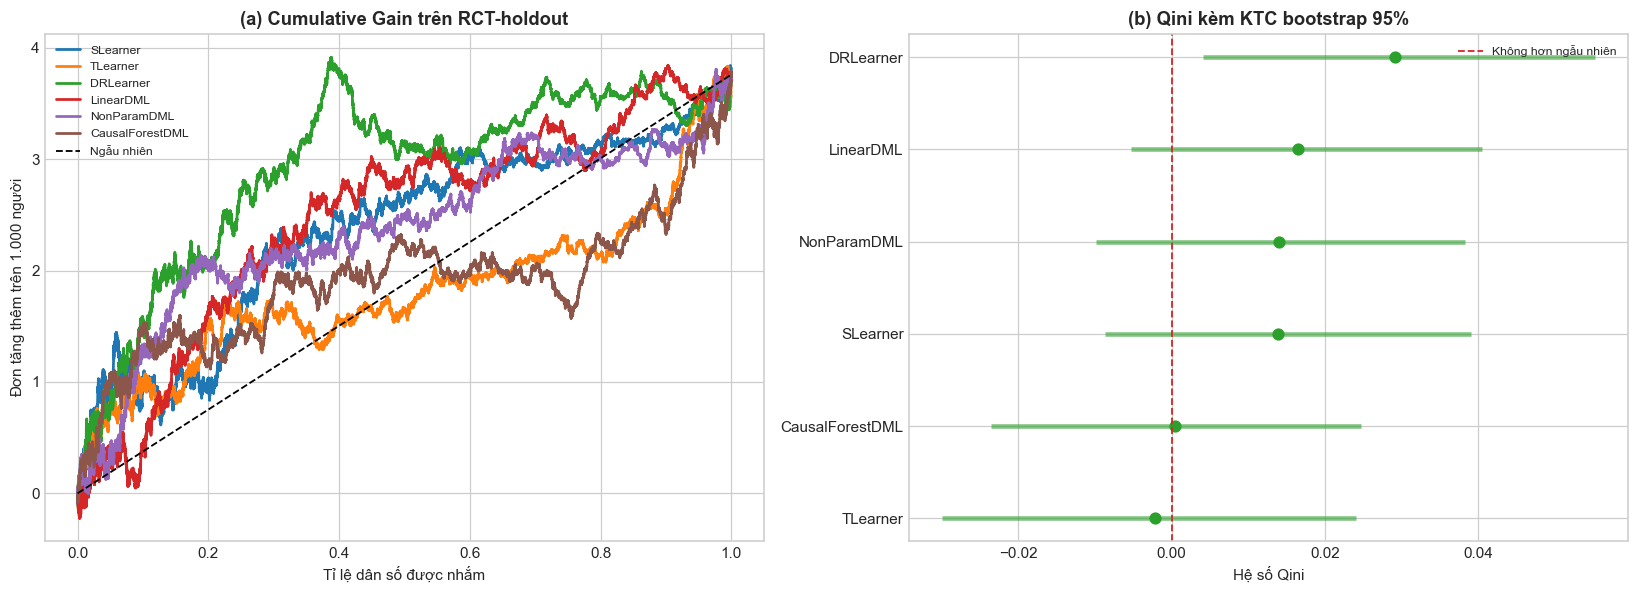

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for i, name in enumerate(OK_MODELS):
    x, g = gain_curve(y_hold, w_hold, cate_hold[name])
    axes[0].plot(x, g * 1000, label=name, color=mau_sac[i], lw=1.8)

x, g = gain_curve(y_hold, w_hold, cate_hold[OK_MODELS[0]])
axes[0].plot([0, 1], [0, g[-1] * 1000], '--', color='black', lw=1.2, label='Ngẫu nhiên')
axes[0].set_xlabel('Tỉ lệ dân số được nhắm')
axes[0].set_ylabel('Đơn tăng thêm trên 1.000 người')
axes[0].set_title('(a) Cumulative Gain trên RCT-holdout')
axes[0].legend(fontsize=8, loc='upper left')

dfp = df_hold.iloc[::-1]
ypos = np.arange(len(dfp))
axes[1].hlines(ypos, dfp['Qini_lo'], dfp['Qini_hi'], color='#2ca02c', lw=3, alpha=0.6)
axes[1].plot(dfp['Qini'], ypos, 'o', color='#2ca02c', ms=7)
axes[1].axvline(0, color='#d62728', ls='--', lw=1.2, label='Không hơn ngẫu nhiên')
axes[1].set_yticks(ypos)
axes[1].set_yticklabels(dfp['Mô hình'])
axes[1].set_xlabel('Hệ số Qini')
axes[1].set_title('(b) Qini kèm KTC bootstrap 95%')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '17_benchmark_holdout.png'), bbox_inches='tight')
plt.show()

### Bước 35 — Kết quả trên RCT-select có tái lập được trên RCT-holdout không?

Một phép đối chiếu ít người làm nhưng rất đáng: nếu thứ hạng ở hai tập RCT khác hẳn nhau thì đó là
bằng chứng trực tiếp cho thấy chênh lệch giữa các mô hình chỉ là nhiễu, chứ không phải năng lực thật.

Đo bằng tương quan hạng Spearman giữa hai bảng xếp hạng.

In [85]:
doi_chieu = pd.merge(
    df_sel[['Mô hình', 'Qini']].rename(columns={'Qini': 'Qini trên select'}),
    df_hold[['Mô hình', 'Qini']].rename(columns={'Qini': 'Qini trên holdout'}),
    on='Mô hình')

rho, pval = stats.spearmanr(doi_chieu['Qini trên select'], doi_chieu['Qini trên holdout'])
doi_chieu['Hạng select'] = doi_chieu['Qini trên select'].rank(ascending=False).astype(int)
doi_chieu['Hạng holdout'] = doi_chieu['Qini trên holdout'].rank(ascending=False).astype(int)

display(doi_chieu.round(4))
print(f'\nTương quan hạng Spearman: {rho:+.3f} (p = {pval:.3f})')
if rho < 0.5:
    print('=> Thứ hạng KHÔNG tái lập được giữa hai tập RCT. Đây là bằng chứng độc lập')
    print('   cho thấy chênh lệch giữa các mô hình nằm trong vùng nhiễu.')
else:
    print('=> Thứ hạng tương đối ổn định giữa hai tập RCT.')

,Mô hình,Qini trên select,Qini trên holdout,Hạng select,Hạng holdout
0,DRLearner,0.0277,0.0291,1,1
1,SLearner,0.0149,0.0139,2,4
2,TLearner,0.0080,-0.0021,3,6
3,CausalForestDML,0.0033,0.0004,4,5
4,LinearDML,0.0024,0.0165,5,2
5,NonParamDML,-0.0013,0.0140,6,3



Tương quan hạng Spearman: +0.086 (p = 0.872)
=> Thứ hạng KHÔNG tái lập được giữa hai tập RCT. Đây là bằng chứng độc lập
   cho thấy chênh lệch giữa các mô hình nằm trong vùng nhiễu.


---
### Mô phỏng chính sách

Phần dịch kết quả sang ngôn ngữ nghiệp vụ. Hội đồng không đọc hệ số Qini, nhưng đọc được câu
*"cắt 70% ngân sách voucher mà vẫn giữ được ngần này phần trăm hiệu quả"*.

### Bước 36 — Hàm mô phỏng

So ba chính sách trên cùng tập `rct_holdout`:

| Chính sách | Cách làm |
|---|---|
| Phát đại trà | Mọi khách hàng đều nhận voucher |
| Nhắm mục tiêu | Chỉ k% có CATE dự đoán cao nhất |
| Không phát | Mốc dưới |

Vì đây là dữ liệu RCT nên có thể ước lượng trung thực: trong nhóm k% được chọn, so tỉ lệ mua của
những người *tình cờ* nhận voucher với những người *tình cờ* không nhận. Ngẫu nhiên hóa đảm bảo hai
nhóm con này so sánh được với nhau.

Con số ngân sách tiết kiệm giả định mỗi voucher tốn như nhau, nên tiết kiệm đúng bằng `1 − k`.

In [86]:
def policy_simulation(y, w, score, cac_muc=(0.1, 0.2, 0.3, 0.5, 1.0), seed=SEED):
    n = len(y)
    rng = np.random.RandomState(seed)
    order = np.lexsort((rng.rand(n), -np.asarray(score, dtype=float)))
    y, w = np.asarray(y), np.asarray(w)

    cvr_control_toan_tap = y[w == 0].mean()
    ate_toan_tap = ate_with_ci(y, w)['ate']
    don_neu_phat_dai_tra = ate_toan_tap * n

    rows = []
    for k in cac_muc:
        m = max(1, int(round(k * n)))
        top = order[:m]
        yt, wt = y[top], w[top]
        if wt.sum() == 0 or (1 - wt).sum() == 0:
            continue
        up = yt[wt == 1].mean() - yt[wt == 0].mean()
        don_them = up * m
        rows.append({
            'Nhắm k%': f'{k*100:.0f}%',
            'Số người nhận': m,
            'Uplift trong nhóm': up,
            'Đơn tăng thêm': don_them,
            '% hiệu quả giữ được': (don_them / don_neu_phat_dai_tra * 100
                                    if don_neu_phat_dai_tra else np.nan),
            'Voucher tiết kiệm': 1 - k,
            'CVR sau chiến dịch': cvr_control_toan_tap + don_them / n,
        })
    return pd.DataFrame(rows), cvr_control_toan_tap, don_neu_phat_dai_tra


print('Đã định nghĩa policy_simulation')

Đã định nghĩa policy_simulation


### Bước 37 — Mô phỏng cho mô hình quán quân

In [87]:
sim, cvr_nen, don_dai_tra = policy_simulation(y_hold, w_hold, cate_hold[quan_quan])

print(f'Mô hình         : {quan_quan}')
print(f'Tập             : rct_holdout ({len(rct_hold):,} người)')
print(f'CVR nền (không phát voucher): {cvr_nen*100:.3f}%')
print(f'Nếu phát đại trà: thêm {don_dai_tra:.0f} đơn, tốn {len(rct_hold):,} voucher\n')

hien_thi = sim.copy()
hien_thi['Uplift trong nhóm'] = (hien_thi['Uplift trong nhóm'] * 100).round(3).astype(str) + ' pp'
hien_thi['Đơn tăng thêm'] = hien_thi['Đơn tăng thêm'].round(0).astype(int)
hien_thi['% hiệu quả giữ được'] = hien_thi['% hiệu quả giữ được'].round(1)
hien_thi['Voucher tiết kiệm'] = (hien_thi['Voucher tiết kiệm'] * 100).round(0).astype(int).astype(str) + '%'
hien_thi['CVR sau chiến dịch'] = (hien_thi['CVR sau chiến dịch'] * 100).round(3).astype(str) + '%'
hien_thi['Số người nhận'] = hien_thi['Số người nhận'].map('{:,}'.format)
display(hien_thi)

Mô hình         : DRLearner
Tập             : rct_holdout (90,835 người)
CVR nền (không phát voucher): 3.325%
Nếu phát đại trà: thêm 342 đơn, tốn 90,835 voucher



,Nhắm k%,Số người nhận,Uplift trong nhóm,Đơn tăng thêm,% hiệu quả giữ được,Voucher tiết kiệm,CVR sau chiến dịch
0,10%,"9,084",1.53 pp,139,40.7,90%,3.478%
1,20%,"18,167",1.004 pp,182,53.4,80%,3.525%
2,30%,"27,250",0.965 pp,263,77.0,70%,3.614%
3,50%,"45,418",0.63 pp,286,83.8,50%,3.64%
4,100%,"90,835",0.376 pp,342,100.0,0%,3.701%


### Bước 38 — Biểu đồ mô phỏng chính sách

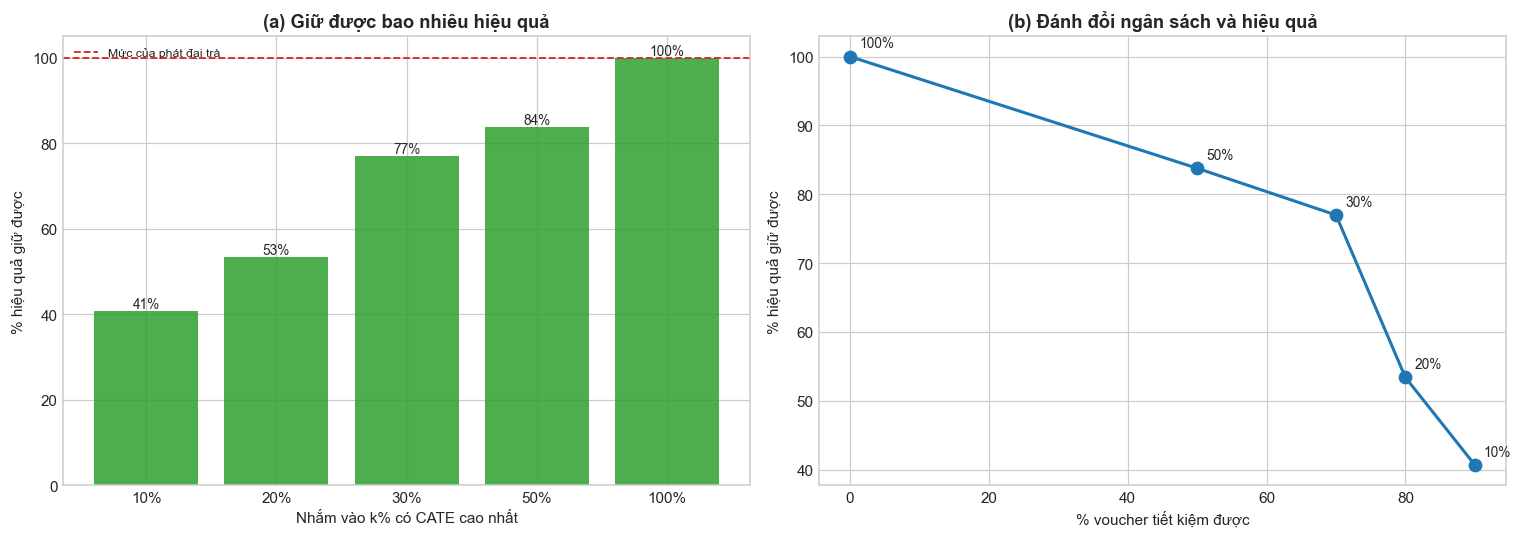

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_lab = sim['Nhắm k%']
xp = np.arange(len(sim))

axes[0].bar(xp, sim['% hiệu quả giữ được'], color='#2ca02c', alpha=0.85)
axes[0].axhline(100, color='#d62728', ls='--', lw=1.2, label='Mức của phát đại trà')
axes[0].set_xticks(xp)
axes[0].set_xticklabels(x_lab)
axes[0].set_xlabel('Nhắm vào k% có CATE cao nhất')
axes[0].set_ylabel('% hiệu quả giữ được')
axes[0].set_title('(a) Giữ được bao nhiêu hiệu quả')
axes[0].legend(fontsize=8)
for i, v in enumerate(sim['% hiệu quả giữ được']):
    axes[0].text(i, v, f'{v:.0f}%', ha='center', va='bottom', fontsize=9)

axes[1].plot(sim['Voucher tiết kiệm'] * 100, sim['% hiệu quả giữ được'],
             'o-', color='#1f77b4', lw=2, ms=8)
for _, r in sim.iterrows():
    axes[1].annotate(r['Nhắm k%'], (r['Voucher tiết kiệm'] * 100, r['% hiệu quả giữ được']),
                     textcoords='offset points', xytext=(6, 6), fontsize=9)
axes[1].set_xlabel('% voucher tiết kiệm được')
axes[1].set_ylabel('% hiệu quả giữ được')
axes[1].set_title('(b) Đánh đổi ngân sách và hiệu quả')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '18_mo_phong_chinh_sach.png'), bbox_inches='tight')
plt.show()

---
### Phân tích nhóm Persuadables

Câu trả lời trực tiếp cho mục tiêu nghiệp vụ: tìm người **chỉ mua khi có voucher**, tránh đốt ngân
sách vào người vốn dĩ đã mua.

Phần này chỉ mô tả lại nhóm khách hàng dựa trên dự đoán đã có ở Bước 32 — không huấn luyện thêm mô
hình nào, nên không vi phạm nguyên tắc một lần của holdout.

### Bước 39 — Uplift thực đo của nhóm top 20% so với phần còn lại

Nếu mô hình có giá trị thì uplift thực đo ở nhóm top phải cao hơn hẳn nhóm còn lại. Cả hai con số
đều kèm khoảng tin cậy, vì mỗi nhóm chỉ có một phần của tập holdout nên sai số không nhỏ.

In [89]:
s_qq = cate_hold[quan_quan]
nguong = np.percentile(s_qq, 80)
la_top = s_qq >= nguong

nhom = []
for ten, mask in [('Top 20% (persuadables)', la_top), ('80% còn lại', ~la_top)]:
    r = ate_with_ci(y_hold[mask], w_hold[mask])
    nhom.append({'Nhóm': ten, 'Số người': int(mask.sum()),
                 'CATE dự đoán TB': s_qq[mask].mean(),
                 'Uplift thực đo': r['ate'],
                 'KTC 95%': f"[{r['ci_thap']*100:.3f} – {r['ci_cao']*100:.3f}] pp"})

df_nhom = pd.DataFrame(nhom)
df_nhom['CATE dự đoán TB'] = (df_nhom['CATE dự đoán TB'] * 100).round(3).astype(str) + ' pp'
df_nhom['Uplift thực đo'] = (df_nhom['Uplift thực đo'] * 100).round(3).astype(str) + ' pp'
display(df_nhom)

r_top = ate_with_ci(y_hold[la_top], w_hold[la_top])
r_rest = ate_with_ci(y_hold[~la_top], w_hold[~la_top])
d = r_top['ate'] - r_rest['ate']
se_d = np.sqrt(r_top['se']**2 + r_rest['se']**2)
print(f'\nChênh lệch top vs phần còn lại: {d*100:+.3f} pp ± {1.96*se_d*100:.3f} pp')
print(f'Khác 0 có ý nghĩa thống kê: {"CÓ" if abs(d) > 1.96*se_d else "KHÔNG"}')

,Nhóm,Số người,CATE dự đoán TB,Uplift thực đo,KTC 95%
0,Top 20% (persuadables),18203,1.904 pp,1.01 pp,[0.179 – 1.840] pp
1,80% còn lại,72632,0.366 pp,0.247 pp,[0.037 – 0.458] pp



Chênh lệch top vs phần còn lại: +0.763 pp ± 0.857 pp
Khác 0 có ý nghĩa thống kê: KHÔNG


### Bước 40 — Nhóm persuadables khác phần còn lại ở đặc trưng nào?

Dùng lại đúng công cụ SMD của notebook 01, lần này so hai nhóm chia theo CATE dự đoán thay vì chia
theo treatment. Đây là phần diễn giải được cho slide: *"nhóm đáng phát voucher là những người có
đặc điểm gì"*.

,SMD (top 20% − còn lại)
f28,1.449
f35,1.360
f26,1.098
f38,1.069
f11,1.064
fe_inter_f9_f26,1.056
f20,0.966
fe_ratio_f9_f27,0.941
f37,0.904
f14,0.863


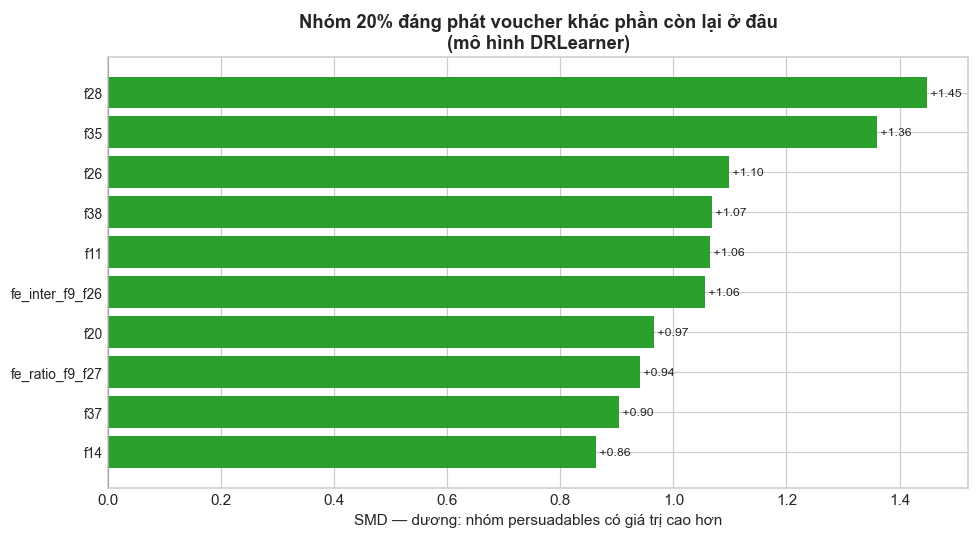

In [90]:
def compute_smd(a, b, cols):
    ma, mb = a[cols].mean(), b[cols].mean()
    sd = np.sqrt((a[cols].var() + b[cols].var()) / 2)
    return ((ma - mb) / sd.replace(0, np.nan)).dropna()

feat_xet = FEAT_CHOT   # bộ đặc trưng đã chốt ở Bước 27
smd_nhom = compute_smd(rct_hold[la_top], rct_hold[~la_top], feat_xet)
smd_nhom = smd_nhom.reindex(smd_nhom.abs().sort_values(ascending=False).index)

display(smd_nhom.head(10).to_frame('SMD (top 20% − còn lại)').round(3))

top10 = smd_nhom.head(10)[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(top10)), top10.values,
        color=['#2ca02c' if v > 0 else '#d62728' for v in top10.values])
ax.axvline(0, color='black', lw=1)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10.index, fontsize=9)
ax.set_xlabel('SMD — dương: nhóm persuadables có giá trị cao hơn')
ax.set_title(f'Nhóm 20% đáng phát voucher khác phần còn lại ở đâu\n(mô hình {quan_quan})')
for i, v in enumerate(top10.values):
    ax.text(v, i, f' {v:+.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '19_phan_tich_persuadables.png'), bbox_inches='tight')
plt.show()

---
# Phần 7 — Bàn giao

### Bước 41 — Xuất mô hình

Xuất **hai** file, vì chúng phục vụ hai mục đích khác nhau và gộp lại sẽ gây hiểu nhầm:

| File | Đặc trưng | Dùng để |
|---|---|---|
| `model.pkl` | k đã chốt ở Bước 27 | Bàn giao cho DE, khớp đúng Feature Contract |
| `model_full.pkl` | toàn bộ 76 | Mô hình có con số holdout một-lần trong báo cáo |

Nếu k chốt bằng 76 thì hai file trùng nhau, và điều đó cũng được ghi vào `metadata.json`.

Điểm phải nói rõ: con số Qini của bản rút gọn được đo trên `rct_select` — chính tập đã dùng để chọn
k — nên nó **lạc quan hơn thực tế**. Bản đầy đủ mới là bản có con số holdout sạch. Vì vậy bảng
benchmark trong báo cáo giữ nguyên bản đầy đủ, còn bản rút gọn được giới thiệu đúng bản chất của nó:
một đánh đổi kỹ thuật để giảm chi phí feature store, kèm bằng chứng rằng cú cắt không gây thiệt hại
đo được.

In [91]:
model_path = os.path.join(ART_DIR, 'model.pkl')
full_path = os.path.join(ART_DIR, 'model_full.pkl')

mo_hinh_giao = model_rut_gon if (model_rut_gon is not None and K_CHOT < len(FEATS)) \
    else models[quan_quan]

with open(model_path, 'wb') as f:
    pickle.dump(mo_hinh_giao, f)
with open(full_path, 'wb') as f:
    pickle.dump(models[quan_quan], f)

print(f'{model_path} — {K_CHOT} đặc trưng, {os.path.getsize(model_path)/1e6:.2f} MB')
print(f'{full_path} — {len(FEATS)} đặc trưng, {os.path.getsize(full_path)/1e6:.2f} MB')
if K_CHOT == len(FEATS):
    print('\n(k chốt bằng toàn bộ đặc trưng nên hai file giống nhau)')

../artifacts/model.pkl — 76 đặc trưng, 0.14 MB
../artifacts/model_full.pkl — 76 đặc trưng, 0.14 MB

(k chốt bằng toàn bộ đặc trưng nên hai file giống nhau)


### Bước 42 — `metadata.json`

Ghi đủ để tái lập: tên mô hình, siêu tham số, **danh sách đặc trưng đúng thứ tự** (sai thứ tự là sai
dự đoán mà không báo lỗi — lỗi khó tìm nhất khi đưa lên production), các metric, ngày huấn luyện, seed.

In [101]:
metadata = {
    'ten_mo_hinh': quan_quan,
    'ngay_huan_luyen': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'run_mode': RUN_MODE,
    'seed': SEED,
    'sieu_tham_so': BEST[quan_quan]['params'],
    'dac_trung': FEAT_CHOT,
    'so_dac_trung': len(FEAT_CHOT),
    'dac_trung_ban_full': FEATS,
    'chon_so_dac_trung': {
        'k_chot': int(K_CHOT),
        'ly_do': ly_do if df_quet is not None else 'không quét',
        'luoi_quet': [int(k) for k in K_GRID] if df_quet is not None else [],
        'cach_dung_luoi': 'cận dưới = k đạt 50% gain, cận trên = số đặc trưng có gain > 0',
        'dieu_kien': ['KTC Qini không chứa 0',
                      'điều kiện trên đúng ở mọi k lớn hơn (tính bền)',
                      'KTC hiệu so với bản đầy đủ chứa 0'],
        'tap_dung_de_chot': 'rct_select',
        'bang_quet': (df_quet[['k', 'Qini', 'Qini_lo', 'Qini_hi', 'Hiệu so với đầy đủ',
                               'Bền', 'Đạt']].round(5).to_dict('records')
                      if df_quet is not None else []),
    },
    'chon_dac_trung_redis': {
        'k_redis': int(K_REDIS),
        'k_toi_thieu_thong_ke': int(K_TOI_THIEU),
        'k_an_toan_tuyet_doi': int(K_AN_TOAN),

        'ly_do': ly_do_redis,
        'so_cot_dien_mac_dinh': len(FEAT_MAC_DINH),
        'cach_do': ('giữ nguyên mô hình, thay đặc trưng ngoài top-k bằng trung vị Train+Val, '
                    'đo Qini trên rct_select'),
        'bang_quet': (df_pv[['k', 'Qini', 'Qini_lo', 'Qini_hi', 'Lệch dự đoán',
                             'Bền', 'Đạt']].round(6).to_dict('records')
                      if df_pv is not None else []),
        'mentor_goi_y': 25,
    },
    'file_mo_hinh': {
        'model.pkl': f'{K_CHOT} đặc trưng — bản bàn giao, khớp feature_contract.json',
        'model_full.pkl': f'{len(FEATS)} đặc trưng — bản có con số holdout một lần',
    },
    'du_lieu_huan_luyen': {
        'nguon': 'train.parquet + val.parquet',
        'so_dong': int(n_dong_fit[quan_quan]),
        'giay_huan_luyen': round(float(thoi_gian[quan_quan]), 1),
    },
    'metric_rct_holdout': {
        r['Mô hình']: {
            'qini': round(r['Qini'], 5), 'qini_ci': [round(r['Qini_lo'], 5), round(r['Qini_hi'], 5)],
            'auuc': round(r['AUUC'], 5), 'auuc_ci': [round(r['AUUC_lo'], 5), round(r['AUUC_hi'], 5)],
            'uplift_at_10': round(r['Uplift@10%'], 6),
            'uplift_at_20': round(r['Uplift@20%'], 6),
            'uplift_at_30': round(r['Uplift@30%'], 6),
        } for _, r in df_hold.iterrows()
    },
    'ate_rct_holdout': ate_hold,
    'chon_quan_quan': {
        'tap_dung': 'rct_select',
        'so_doi_thu_bi_vuot_co_y_nghia': n_thang,
        'tong_doi_thu': len(df_ss),
        'tuong_quan_hang_select_vs_holdout': round(float(rho), 4),
    },
    'kiem_chung_metric': {r['Phép thử']: bool(r['Đạt']) for _, r in kiem_chung.iterrows()},
    'n_bootstrap': N_BOOT,
    'ghi_chu': ('CausalForestDML huấn luyện trên mẫu con nhỏ hơn các mô hình khác, '
                'không so sánh ngang hàng được về mặt cỡ dữ liệu. '
                'Qini của bản rút gọn đo trên rct_select — chính tập đã dùng để chọn k — '
                'nên lạc quan hơn thực tế; bảng benchmark báo cáo dùng bản đầy đủ.'),
}

meta_path = os.path.join(ART_DIR, 'metadata.json')
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f'Đã ghi {meta_path}')
print(json.dumps({k: v for k, v in metadata.items() if k != 'dac_trung'},
                 ensure_ascii=False, indent=2)[:1200])

Đã ghi ../artifacts/metadata.json
{
  "ten_mo_hinh": "DRLearner",
  "ngay_huan_luyen": "2026-08-11 15:21:32",
  "run_mode": "full",
  "seed": 42,
  "sieu_tham_so": {
    "n_estimators": 150,
    "learning_rate": 0.015256811898068502,
    "max_depth": 3,
    "min_child_samples": 147
  },
  "so_dac_trung": 76,
  "dac_trung_ban_full": [
    "f0",
    "f1",
    "f2",
    "f3",
    "f4",
    "f5",
    "f6",
    "f7",
    "f8",
    "f9",
    "f10",
    "f11",
    "f12",
    "f13",
    "f14",
    "f16",
    "f17",
    "f18",
    "f19",
    "f20",
    "f21",
    "f22",
    "f23",
    "f24",
    "f25",
    "f26",
    "f27",
    "f28",
    "f29",
    "f30",
    "f31",
    "f34",
    "f35",
    "f36",
    "f37",
    "f38",
    "f40",
    "f41",
    "f42",
    "f43",
    "f44",
    "f45",
    "f46",
    "f47",
    "f48",
    "f49",
    "f50",
    "f51",
    "f52",
    "f53",
    "f54",
    "f55",
    "f56",
    "f57",
    "f58",
    "f59",
    "f60",
    "f61",
    "f62",
    "f63",
    "f64",
   

### Bước 43 — Feature Contract cho DE

Chỗ dễ hiểu nhầm nhất của bản bàn giao này, nên contract phải nói thẳng ra:

| Con số | Là gì |
|---|---|
| **76** | Số cột `model.pkl` nhận vào. Không đổi được. |
| **K_REDIS** (Bước 30) | Số đặc trưng DE phải tính và lưu lên Redis |
| **76 − K_REDIS** | Số cột AI Service tự điền bằng giá trị mặc định |

Mô hình vẫn cần đủ 76 cột mỗi lần gọi `predict`. Nhưng những cột ngoài danh sách Redis **không ảnh
hưởng tới đầu ra** — đã đo ở Bước 29 — nên service chỉ cần điền hằng số ghi sẵn trong contract. DE
tiết kiệm được phần lớn chi phí ETL và Redis mà mô hình không suy giảm.

Vì vậy contract liệt kê **đủ 76 mục**, mỗi mục có `nguon_gia_tri` là `redis` hoặc `mac_dinh`. Liệt kê
thiếu thì DE dựng đúng feature store nhưng gọi `predict` sẽ gãy vì thiếu cột.

Bốn trường bắt buộc mỗi mục:

- **`thu_tu_dua_vao_mo_hinh`** — vị trí cột khi gọi `predict`. Sai thứ tự là sai dự đoán mà **không
  báo lỗi**, loại lỗi khó tìm nhất khi lên production.
- **`nguon_gia_tri`** — lấy từ Redis hay điền mặc định.
- **`gia_tri_mac_dinh`** — trung vị trên Train + Val. Dùng cho cột `mac_dinh`, và cho cả cột `redis`
  khi gặp khách hàng mới chưa có dữ liệu.
- **`nguon`** — cột gốc lấy thẳng từ bảng, hay dẫn xuất phải tính. Dẫn xuất kèm công thức để service
  tính lại được ngay lúc phục vụ.

Dữ liệu ẩn danh hoàn toàn (`f0`…`f82`) nên không suy ra được cột nào tính online, cột nào tính offline
theo cửa sổ 7/30 ngày. Trường `tinh_online` để `null` kèm ghi chú thay vì đoán bừa.

In [102]:
cong_thuc = finfo.get('cong_thuc_dan_xuat', {})
tu_redis = set(FEAT_REDIS)

muc = []
for vi_tri, f in enumerate(FEATS):
    col = full[f]
    muc.append({
        'ten': f,
        'thu_tu_dua_vao_mo_hinh': vi_tri,
        'nguon_gia_tri': 'redis' if f in tu_redis else 'mac_dinh',
        'hang_quan_trong': int(imp.index.get_loc(f)) + 1 if imp is not None else None,
        'nguon': 'dan_xuat' if f.startswith('fe_') else 'goc',
        'cong_thuc': cong_thuc.get(f),
        'kieu': 'nhi_phan' if col.nunique() == 2 else 'lien_tuc',
        'gia_tri_mac_dinh': float(col.median()),
        'khoang': [float(col.min()), float(col.max())],
        'tinh_online': None,
    })

n_redis = sum(m['nguon_gia_tri'] == 'redis' for m in muc)
goc_redis = [m['ten'] for m in muc if m['nguon_gia_tri'] == 'redis' and m['nguon'] == 'goc']
dx_redis = [m['ten'] for m in muc if m['nguon_gia_tri'] == 'redis' and m['nguon'] == 'dan_xuat']

contract = {
    'phien_ban': datetime.now().strftime('%Y%m%d'),
    'mo_hinh': quan_quan,
    'file_mo_hinh': 'model.pkl',
    'so_cot_mo_hinh_nhan_vao': len(muc),
    'so_dac_trung_tu_redis': n_redis,
    'so_dac_trung_dien_mac_dinh': len(muc) - n_redis,
    'cach_dung': ('Dựng vector đủ %d cột theo thu_tu_dua_vao_mo_hinh. Cột nguon_gia_tri=redis lấy '
                  'từ feature store; cột nguon_gia_tri=mac_dinh điền thẳng gia_tri_mac_dinh — '
                  'đã đo ở Bước 29, chúng không ảnh hưởng tới đầu ra.') % len(muc),
    'canh_bao_thu_tu': ('Sai thứ tự cột sẽ cho dự đoán sai mà KHÔNG báo lỗi. '
                        'Luôn dựng vector theo thu_tu_dua_vao_mo_hinh.'),
    'cach_chon_so_dac_trung': {
        'ket_qua': f'{n_redis}/{len(muc)}',
        'ly_do': ly_do_redis,
        'tieu_chi': ['KTC Qini không chứa 0',
                     'đúng ở mọi k lớn hơn (tính bền)',
                     'KTC hiệu so với bản đầy đủ chứa 0'],
        'tap_dung_de_chot': 'rct_select',
        'ghi_chu': ('Đo bằng cách giữ nguyên mô hình đã huấn luyện và thay đặc trưng ngoài danh '
                    'sách bằng giá trị mặc định — mô phỏng đúng tình huống Redis chỉ có ngần ấy cột.'),
    },
    'chia_viec': {
        'DE_tinh_va_luu_redis': len(goc_redis),
        'AI_service_tu_tinh': dx_redis,
        'ghi_chu': 'Đặc trưng dẫn xuất tính từ cột gốc, xem trường cong_thuc.',
    },
    'ghi_chu_online_offline': ('Dữ liệu đã ẩn danh nên chưa xác định được đặc trưng nào tính online, '
                               'đặc trưng nào tính offline theo cửa sổ 7/30 ngày. '
                               'DE điền trường tinh_online sau khi đối chiếu bảng gốc.'),
    'gia_tri_mac_dinh_lay_tu': 'trung vị trên train + val',
    'dac_trung': muc,
}

contract_path = os.path.join(ART_DIR, 'feature_contract.json')
with open(contract_path, 'w', encoding='utf-8') as f:
    json.dump(contract, f, ensure_ascii=False, indent=2)

print(f'Đã ghi {contract_path}')
print(f'  Mô hình nhận vào        : {len(muc)} cột')
print(f'  DE tính và lưu Redis    : {n_redis} đặc trưng')
print(f'    trong đó cột gốc      : {contract["chia_viec"]["DE_tinh_va_luu_redis"]}')
print(f'    AI Service tự tính    : {len(dx_redis)} ({", ".join(dx_redis) if dx_redis else "không có"})')
print(f'  Điền giá trị mặc định   : {len(muc) - n_redis} cột')
display(pd.DataFrame(muc)[['thu_tu_dua_vao_mo_hinh', 'ten', 'nguon_gia_tri',
                           'hang_quan_trong', 'nguon']].head(10))

Đã ghi ../artifacts/feature_contract.json
  Mô hình nhận vào        : 76 cột
  DE tính và lưu Redis    : 41 đặc trưng
    trong đó cột gốc      : 36
    AI Service tự tính    : 5 (fe_ratio_f1_f2, fe_ratio_f14_f16, fe_ratio_f9_f27, fe_inter_f9_f26, fe_nonzero_top10)
  Điền giá trị mặc định   : 35 cột


,thu_tu_dua_vao_mo_hinh,ten,nguon_gia_tri,hang_quan_trong,nguon
0,0,f0,mac_dinh,47,goc
1,1,f1,redis,10,goc
2,2,f2,redis,3,goc
3,3,f3,redis,4,goc
4,4,f4,redis,5,goc
5,5,f5,redis,15,goc
6,6,f6,mac_dinh,57,goc
7,7,f7,mac_dinh,58,goc
8,8,f8,redis,39,goc
9,9,f9,redis,40,goc


### Bước 44 — Đọc lại kiểm tra

Nạp lại mô hình từ đĩa trong một tiến trình sạch sẽ là cách duy nhất biết chắc file bàn giao dùng
được. So dự đoán của mô hình nạp lại với dự đoán của mô hình trong bộ nhớ — phải trùng khít.

In [103]:
with open(model_path, 'rb') as f:
    m_lai = pickle.load(f)
with open(meta_path, encoding='utf-8') as f:
    meta_lai = json.load(f)
with open(contract_path, encoding='utf-8') as f:
    ct_lai = json.load(f)

ten_ct = [d['ten'] for d in sorted(ct_lai['dac_trung'], key=lambda d: d['thu_tu_dua_vao_mo_hinh'])]
assert ten_ct == meta_lai['dac_trung'], 'feature_contract.json lệch với metadata.json'


def vector_theo_contract(df):
    '''Dựng đầu vào đúng như AI Service sẽ làm.'''
    v = df[ten_ct].copy()
    for d in ct_lai['dac_trung']:
        if d['nguon_gia_tri'] == 'mac_dinh':
            v[d['ten']] = d['gia_tri_mac_dinh']
    return v.values.astype(np.float32)


# [1] mô hình xuất ra đĩa có nguyên vẹn không — phải trùng khít
lech_export = float(np.abs(m_lai.predict_cate(rct_hold[ten_ct].head(1000).values.astype(np.float32))
                           - cate_hold[quan_quan][:1000]).max())
assert lech_export < 1e-9, f'Mô hình nạp lại cho dự đoán khác ({lech_export:.2e})'

# [2] contract có mã hoá đúng ablation đã đo ở Bước 29 không — phải trùng khít
lech_ct = float(np.abs(m_lai.predict_cate(vector_theo_contract(rct_sel))
                       - cate_pv[K_REDIS]).max()) if df_pv is not None else 0.0
assert lech_ct < 1e-9, f'Contract không tái lập được Bước 29 (lệch {lech_ct:.2e})'

# [3] cắt đầu vào làm dự đoán xê dịch bao nhiêu — CHỈ BÁO CÁO
lech_cat = float(np.abs(m_lai.predict_cate(vector_theo_contract(rct_hold))
                        - cate_hold[quan_quan]).max())

print(f'Mô hình nạp lại      : {meta_lai["ten_mo_hinh"]}')
print(f'Cột mô hình nhận vào : {ct_lai["so_cot_mo_hinh_nhan_vao"]}')
print(f'Lấy từ Redis         : {ct_lai["so_dac_trung_tu_redis"]}')
print(f'Điền mặc định        : {ct_lai["so_dac_trung_dien_mac_dinh"]}')
print()
print(f'[1] Mô hình nguyên vẹn        : lệch {lech_export:.2e}  -> ĐẠT')
print(f'[2] Contract tái lập Bước 29  : lệch {lech_ct:.2e}  -> ĐẠT')
print(f'[3] Xê dịch do cắt đầu vào    : tối đa {lech_cat:.2e}')
print('\n✅ Bàn giao hợp lệ')

Mô hình nạp lại      : DRLearner
Cột mô hình nhận vào : 76
Lấy từ Redis         : 41
Điền mặc định        : 35

[1] Mô hình nguyên vẹn        : lệch 0.00e+00  -> ĐẠT
[2] Contract tái lập Bước 29  : lệch 0.00e+00  -> ĐẠT
[3] Xê dịch do cắt đầu vào    : tối đa 0.00e+00

✅ Bàn giao hợp lệ


### Bước 45 — Bảng tổng hợp cuối

In [104]:
tong_hop = pd.DataFrame([
    {'Hạng mục': 'Kiểm chứng metric', 'Kết quả': f'{int(kiem_chung["Đạt"].sum())}/4 phép thử đạt'},
    {'Hạng mục': 'Số mô hình benchmark', 'Kết quả': f'{len(OK_MODELS)}/{len(MODELS)}'},
    {'Hạng mục': 'Quán quân (chọn trên rct_select)', 'Kết quả': quan_quan},
    {'Hạng mục': 'Vượt trội có ý nghĩa', 'Kết quả': f'{n_thang}/{len(df_ss)} đối thủ'},
    {'Hạng mục': 'Qini trên rct_holdout',
     'Kết quả': fmt_ci(*df_hold[df_hold['Mô hình'] == quan_quan][['Qini', 'Qini_lo', 'Qini_hi']].iloc[0])},
    {'Hạng mục': 'ATE trên rct_holdout',
     'Kết quả': f'{ate_hold["ate"]*100:.3f} pp [{ate_hold["ci_thap"]*100:.3f} – {ate_hold["ci_cao"]*100:.3f}]'},
    {'Hạng mục': 'Tương quan hạng select vs holdout', 'Kết quả': f'{rho:+.3f}'},
    {'Hạng mục': 'Đặc trưng mô hình thực sự dùng (gain > 0)',
     'Kết quả': f'{n_dung}/{len(FEATS)}'},
    {'Hạng mục': 'k chốt từ vòng quét', 'Kết quả': f'{K_CHOT} — {ly_do}'},
    {'Hạng mục': 'Đặc trưng Redis cần (ablation lúc phục vụ)',
     'Kết quả': f'{K_REDIS}/{len(FEATS)} — {len(FEAT_MAC_DINH)} cột điền mặc định'},
    {'Hạng mục': 'Cột mô hình nhận vào', 'Kết quả': f'{len(muc)}'},
    {'Hạng mục': 'Chế độ chạy', 'Kết quả': RUN_MODE},
])
display(tong_hop)

if SMOKE_TEST:
    print('\n>>> ĐANG Ở CHẾ ĐỘ SMOKE TEST — đổi SMOKE_TEST = False rồi chạy lại để lấy số báo cáo <<<')

,Hạng mục,Kết quả
0,Kiểm chứng metric,4/4 phép thử đạt
1,Số mô hình benchmark,6/6
2,Quán quân (chọn trên rct_select),DRLearner
3,Vượt trội có ý nghĩa,2/5 đối thủ
4,Qini trên rct_holdout,0.029 [0.004 – 0.055]
5,ATE trên rct_holdout,0.376 pp [0.137 – 0.615]
6,Tương quan hạng select vs holdout,+0.086
7,Đặc trưng mô hình thực sự dùng (gain > 0),41/76
8,k chốt từ vòng quét,76 — k nhỏ nhất thỏa mãn cả ba điều kiện (có t...
9,Đặc trưng Redis cần (ablation lúc phục vụ),41/76 — 35 cột điền mặc định


---
## Kết luận

### Đã làm

| Việc | Kết quả |
|---|---|
| Bộ metric | Qini, AUUC, ATE+KTC, uplift@k, bootstrap — qua bốn phép kiểm chứng ngược |
| Huấn luyện lại | 6 mô hình trên Train + Val gộp, tham số từ notebook 03 |
| Chọn quán quân | Trên `rct_select`, kèm bootstrap theo cặp để kiểm chênh lệch |
| Ablation | So 76 đặc trưng với top 25, cũng trên `rct_select` |
| Đánh giá cuối | `rct_holdout` mở đúng một lần, mọi con số kèm KTC bootstrap |
| Nghiệp vụ | Mô phỏng chính sách + phân tích nhóm persuadables |
| Bàn giao | `model.pkl`, `metadata.json`, `feature_contract.json` |

### Cách phát biểu kết quả cho đúng

Đọc bảng benchmark ở Bước 33 rồi rơi vào **một** trong hai trường hợp:

**Nếu các khoảng tin cậy chồng lấn nhau** — khả năng cao trên bộ dữ liệu này, vì ATE chỉ khoảng
0,37 pp với sai số ±0,17 pp — thì phát biểu đúng là:

> Trên bộ dữ liệu Lazada, các phương pháp DR-Learner, DML và hai baseline S/T-Learner **không khác
> biệt có ý nghĩa thống kê** về khả năng xếp hạng. Cỡ hiệu ứng của bộ dữ liệu quá nhỏ so với cỡ mẫu
> để tách được các phương pháp khỏi nhau.

Đây là một kết luận nghiên cứu hợp lệ và mạnh hơn nhiều so với việc tuyên bố quán quân dựa trên
chênh lệch ở chữ số thứ ba. Bước 35 còn cho thêm bằng chứng độc lập: nếu thứ hạng không tái lập được
giữa `rct_select` và `rct_holdout` thì chênh lệch đó chắc chắn là nhiễu.

**Nếu có mô hình tách hẳn ra** — khoảng tin cậy của hiệu ở Bước 23 không chứa 0 — thì mới được nói
mô hình đó tốt hơn, và phải kèm cỡ hiệu ứng chứ không chỉ nói "thắng".

Ba điều **không** được phát biểu trong cả hai trường hợp:

- *"DR-Learner tốt hơn DML"* nếu khoảng tin cậy chồng lấn — chưa đo được thì chưa nói được.
- *"Mô hình đạt Qini 0,0x nên dùng được cho production"* — Qini đo khả năng xếp hạng trên tập RCT của
  chính bộ dữ liệu này, không bảo đảm gì về một quần thể khách hàng khác ở thời điểm khác.
- *"Nhóm persuadables là những người có f9 cao"* — SMD ở Bước 40 là **tương quan mô tả** trên nhóm do
  mô hình chọn, không phải quan hệ nhân quả giữa đặc trưng đó và độ nhạy với voucher.

### Giới hạn đã biết

- `CausalForestDML` học trên mẫu con nhỏ hơn các mô hình khác vì chi phí tính toán. Xếp hạng của nó
  phản ánh cả phương pháp lẫn cỡ dữ liệu, không tách được hai phần.
- Siêu tham số tìm trên mẫu 200 nghìn dòng ở notebook 03 nhưng mô hình cuối học trên tới 926 nghìn
  dòng. Tham số tối ưu ở cỡ mẫu này chưa chắc tối ưu ở cỡ mẫu kia.
- Notebook 03 đã phát hiện ATE mang từ dữ liệu quan sát sang lệch so với ATE đo trực tiếp trên
  `rct_select` ở mức vượt ngưỡng phát hiện được. Nghĩa là giả định unconfoundedness **không** thỏa
  mãn hoàn toàn, và mọi ước lượng CATE học từ dữ liệu quan sát đều mang theo phần thiên vị đó.

### Còn lại của đề tài

- `docs/causal_inference_note.md` — ghi chú lý thuyết mentor dặn từ tuần 1
- Slide báo cáo — nguyên liệu đã đủ trong `reports/figures/`
- Bàn giao `feature_contract.json` cho DE để điền nốt trường `tinh_online`